# ChimpUFE Intensive Fine-Tune — Test Evaluation

This notebook evaluates the **intensive fine-tuning run** (`chimpUFE_finetune_intensive.py`) on the held-out **test set** and compares it against the original **ChimpUFE 340k pretrained** backbone.

It loads `best_model.pt` from a run directory, rebuilds `ChimpIdentityNet`, and runs:

1. **Classification metrics** (softmax head): top-1, top-5, per-class accuracy, F1, confusion matrix on test
2. **Retrieval metrics** (cosine NN, leave-one-out): top-1, top-5, mAP
3. **Prototype retrieval** using train tier-1 as gallery (the realistic deployment setting)
4. **Verification metrics**: ROC-AUC, EER, score distributions
5. **Embedding geometry**: intra/inter-class cosine, t-SNE / PCA, silhouette
6. **Confidence calibration**: margin distribution for correct vs wrong, reliability curve
7. **Open-set rejection**: how thresholding similarity affects accuracy
8. **Side-by-side image inspection** of failures
9. **Direct comparison** with pretrained 340k (delta tables + projections)


In [1]:
import json
import math
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    precision_recall_fscore_support, silhouette_score,
)

sys.path.append(str(Path("../../../")))
import chimplib.recognition_utils as ru
import importlib
from facenet_pytorch import InceptionResnetV1 

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

sns.set_theme(context="paper", style="whitegrid")
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/ucl/ingi/trixen/ChimpRec/.venv/lib/python3.10/site-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
/home/ucl/ingi/trixen/ChimpRec/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
#=============================================================================
# Paths — change RUN_DIR to the run you want to evaluate
# =============================================================================
REPO_ROOT = Path("../../../../").resolve()
print("Repo root:", REPO_ROOT)

# Auto-pick the most recent intensive run (override if you want a specific one)
RUNS_ROOT = REPO_ROOT / "Code/Recognition/FaceEmbedder_finetuning/finetuning/runs"
EVAL_DIR = REPO_ROOT / "Code/Recognition/FaceEmbedder_finetuning/Evaluation"
CHIMBLIB_DIR = REPO_ROOT / "Code/chimplib"

candidate_runs = sorted(RUNS_ROOT.glob("chimpufe_ft_t3_frontal55"))
assert candidate_runs, f"No intensive runs found under {RUNS_ROOT}"
RUN_DIR = candidate_runs[-1]
# RUN_DIR = RUNS_ROOT / "chimpufe_intensive_20260422_194224"   # uncomment to pin

CKPT_PATH       = RUN_DIR / "best_model.pt"
RUN_CONFIG_PATH = RUN_DIR / "run_config.json"
EVAL_OUT_DIR    = EVAL_DIR / str("test_eval" + "_" + RUN_DIR.name)
EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Tier-1 face crops (YOLOX-extracted from the original full-body images).
# These match what the trainer saw at TRAIN_ROOT / VAL_ROOT.
DB_ROOT   = REPO_ROOT / "ChimpPic/face_recognition_db"
TRAIN_DIR = DB_ROOT / "Tier1" / "chimpRecV1_faces" / "train"
VAL_DIR   = DB_ROOT / "Tier1" / "chimpRecV1_faces" / "val"
TEST_DIR  = DB_ROOT / "Test" / "test_final"

FACENET_FC_CKPT = REPO_ROOT / "Models/Face Recognition/facenet_16_layers_fc.pth"
PRETRAINED_CKPT = REPO_ROOT / "Models/Face Recognition/25-08-29T11-49-28_340k.pth"
CHIMPUFE_SRC    = CHIMBLIB_DIR / "ChimpUFE/src"
TRAINING_SCRIPT = REPO_ROOT / "Code/Recognition/FaceEmbedder_finetuning/finetuning/full_chimpUFE_finetuning.py"

for p in [CKPT_PATH, TEST_DIR, TRAIN_DIR, VAL_DIR, PRETRAINED_CKPT, CHIMPUFE_SRC, TRAINING_SCRIPT]:
    assert p.exists(), f"Missing: {p}"

print("RUN_DIR        :", RUN_DIR)
print("CKPT_PATH      :", CKPT_PATH)
print("TRAIN_DIR      :", TRAIN_DIR)
print("VAL_DIR        :", VAL_DIR)
print("TEST_DIR       :", TEST_DIR)
print("EVAL_OUT_DIR   :", EVAL_OUT_DIR)

Repo root: /home/users/t/r/trixen/ChimpRec
RUN_DIR        : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/finetuning/runs/chimpufe_ft_t3_frontal55
CKPT_PATH      : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/finetuning/runs/chimpufe_ft_t3_frontal55/best_model.pt
TRAIN_DIR      : /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1_faces/train
VAL_DIR        : /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1_faces/val
TEST_DIR       : /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Test/test_final
EVAL_OUT_DIR   : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55


In [3]:
# =============================================================================
# Reuse the EXACT model + name-resolution code from the training script
# (so architecture / class indexing match the checkpoint)
# =============================================================================
TRAIN_SCRIPT_DIR = TRAINING_SCRIPT.parent
if str(TRAIN_SCRIPT_DIR) not in sys.path:
    sys.path.append(str(TRAIN_SCRIPT_DIR))

import importlib
import full_chimpUFE_finetuning as ftmod
importlib.reload(ftmod)

CANONICAL_NAMES         = ftmod.CANONICAL_NAMES
canonical_name          = ftmod.canonical_name
name_from_test_filename = ftmod.name_from_test_filename
build_chimpufe_backbone = ftmod.build_chimpufe_backbone
ChimpIdentityNet        = ftmod.ChimpIdentityNet

print(f"Loaded {len(CANONICAL_NAMES)} canonical chimp identities.")

Loaded 20 canonical chimp identities.


In [4]:
# =============================================================================
# Datasets / loaders for test, val, and train (train used as gallery)
# =============================================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

eval_size = 224
eval_tfm = transforms.Compose([
    transforms.Resize((eval_size, eval_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FlatTestDataset(Dataset):
    """Reads test/*.png|jpg, label inferred from filename via name_from_test_filename."""
    def __init__(self, root: Path, transform):
        self.transform = transform
        self.samples = []
        for p in sorted(root.iterdir()):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                lbl = name_from_test_filename(p.name)
                if lbl is None:
                    print(f"  [skip - cannot resolve label] {p.name}")
                    continue
                self.samples.append((p, lbl))
        assert self.samples, f"No test images in {root}"

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label, str(path)


class FolderDataset(Dataset):
    """Reads root/<chimp>/*.png|jpg layout used by train/ and val/."""
    def __init__(self, root: Path, transform):
        self.transform = transform
        self.samples = []
        for chimp_dir in sorted(p for p in root.iterdir() if p.is_dir()):
            lbl = canonical_name(chimp_dir.name)
            if lbl is None:
                continue
            for img_path in sorted(chimp_dir.iterdir()):
                if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
                    self.samples.append((img_path, lbl))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label, str(path)


test_ds = FlatTestDataset(TEST_DIR, eval_tfm)
val_ds   = FolderDataset(VAL_DIR, eval_tfm)
train_ds = FolderDataset(TRAIN_DIR, eval_tfm)

mk = lambda ds, bs=64: DataLoader(ds, batch_size=bs, shuffle=False,
                                  num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = mk(test_ds)
val_loader   = mk(val_ds)
train_loader = mk(train_ds)

print(f"test  : {len(test_ds)} images, {len({l for _,l in test_ds.samples})} ids")
print(f"val   : {len(val_ds)}  images, {len({l for _,l in val_ds.samples})} ids")
print(f"train : {len(train_ds)} images, {len({l for _,l in train_ds.samples})} ids (gallery)")

test  : 500 images, 20 ids
val   : 227  images, 20 ids
train : 866 images, 20 ids (gallery)


In [5]:
# =============================================================================
# Build & load the fine-tuned ChimpIdentityNet from the run checkpoint
# =============================================================================
ckpt = torch.load(str(CKPT_PATH), map_location="cpu", weights_only=False)
class_to_idx = ckpt["class_to_idx"]
idx_to_class = {i: n for n, i in class_to_idx.items()}
cfg = ckpt.get("config", {})
print(f"Checkpoint epoch={ckpt.get('epoch')} stage={ckpt.get('stage')} val_top1={ckpt.get('val_top1', 0):.4f}")
print(f"Num classes: {len(class_to_idx)}")

backbone = build_chimpufe_backbone(CHIMPUFE_SRC, PRETRAINED_CKPT)
fine_model = ChimpIdentityNet(
    backbone=backbone,
    num_classes=len(class_to_idx),
    image_size=eval_size,
    use_arcface=cfg.get("use_arcface", True),
    dropout=cfg.get("dropout", 0.2),
    arc_s=cfg.get("arc_s", 30.0),
    arc_m=cfg.get("arc_m", 0.30),
)
# Prefer EMA weights if present (training script saves both)
state = ckpt.get("ema_state") or ckpt["model_state"]
missing, unexpected = fine_model.load_state_dict(state, strict=False)
print(f"Loaded fine-tuned. Missing={len(missing)} Unexpected={len(unexpected)}")
fine_model.to(device).eval()
print()


Checkpoint epoch=14 stage=stage2_full_finetune val_top1=0.8891
Num classes: 20
Backbone loaded. Missing: 0  Unexpected: 8
Loaded fine-tuned. Missing=0 Unexpected=0



In [6]:
# =============================================================================
# Embedding & logits extractors
# =============================================================================
@torch.no_grad()
def extract_embeddings_and_logits(model, loader, device, has_classifier=True):
    """For ChimpIdentityNet: returns L2-normalized features and class logits (cosine*s if arcface)."""
    model.eval()
    embs, logits_all, labels, paths = [], [], [], []
    for imgs, lbls, pths in loader:
        imgs = imgs.to(device, non_blocking=True)
        feat = model.features(imgs)
        embs.append(F.normalize(feat, dim=1).cpu().numpy())
        if has_classifier:
            if model.use_arcface:
                logits = model.head(feat, labels=None)  # cosine * s
            else:
                logits = model.head(feat)
            logits_all.append(logits.cpu().numpy())
        labels.extend(list(lbls))
        paths.extend(list(pths))
    emb = np.concatenate(embs, axis=0).astype(np.float32)
    lg  = np.concatenate(logits_all, axis=0).astype(np.float32) if has_classifier else None
    return emb, lg, labels, paths


@torch.no_grad()
def extract_features_only(model_callable, loader, device):
    """For arbitrary backbone (e.g. raw pretrained vit_base) returning a feature tensor."""
    embs, labels, paths = [], [], []
    for imgs, lbls, pths in loader:
        imgs = imgs.to(device, non_blocking=True)
        z = model_callable(imgs)
        embs.append(F.normalize(z, dim=1).cpu().numpy())
        labels.extend(list(lbls))
        paths.extend(list(pths))
    return np.concatenate(embs, axis=0).astype(np.float32), labels, paths


print("Extracting fine-tuned embeddings (test, val, train)...")
ft_test_emb,  ft_test_logits,  ft_test_labels,  ft_test_paths  = extract_embeddings_and_logits(fine_model, test_loader,  device)
ft_val_emb,   ft_val_logits,   ft_val_labels,   ft_val_paths   = extract_embeddings_and_logits(fine_model, val_loader,   device)
ft_train_emb, _,                ft_train_labels, ft_train_paths = extract_embeddings_and_logits(fine_model, train_loader, device)
print(f"  test:  {ft_test_emb.shape}, val: {ft_val_emb.shape}, train: {ft_train_emb.shape}")


Extracting fine-tuned embeddings (test, val, train)...
  test:  (500, 768), val: (227, 768), train: (866, 768)


In [7]:
# =============================================================================
# Build pretrained-only backbone (no fine-tune) for comparison
# =============================================================================
print("Loading raw ChimpUFE 340k backbone (no fine-tune)...")
pre_backbone = build_chimpufe_backbone(CHIMPUFE_SRC, PRETRAINED_CKPT).to(device).eval()

print("Extracting pretrained embeddings (test, train)...")
pt_test_emb,  pt_test_labels,  pt_test_paths  = extract_features_only(pre_backbone, test_loader,  device)
pt_train_emb, pt_train_labels, pt_train_paths = extract_features_only(pre_backbone, train_loader, device)
print(f"  test: {pt_test_emb.shape}, train: {pt_train_emb.shape}")

assert ft_test_paths  == pt_test_paths,  "Test path order mismatch"
assert ft_train_paths == pt_train_paths, "Train path order mismatch"


Loading raw ChimpUFE 340k backbone (no fine-tune)...
Backbone loaded. Missing: 0  Unexpected: 8
Extracting pretrained embeddings (test, train)...
  test: (500, 768), train: (866, 768)


In [8]:
# =============================================================================
# 12) FaceNet-FC (last year's model) — load
# =============================================================================
facenet_sd = torch.load(str(FACENET_FC_CKPT), map_location="cpu", weights_only=False)
fn_num_classes = facenet_sd["fc.weight"].shape[0]
print(f"num_classes : {fn_num_classes}")

facenet_model = ru.CustomFCLFaceNet(num_classes=fn_num_classes)
missing, unexpected = facenet_model.load_state_dict(facenet_sd, strict=False)
print(f"Missing : {len(missing)} (expected 0)")
print(f"Unexpected: {len(unexpected)} (expected backbone.logits.weight / .bias only)")
if unexpected:
    print(" Unexpected keys:", unexpected)

facenet_model.to(device).eval()
facenet_backbone = facenet_model.backbone # InceptionResnetV1 → 512-d
print("FaceNet FC model ready.")

num_classes : 20
Missing : 0 (expected 0)
Unexpected: 0 (expected backbone.logits.weight / .bias only)
FaceNet FC model ready.


In [9]:
# =============================================================================
# 12b) FaceNet-FC — transform (160×160), loaders, extract embeddings
# =============================================================================
facenet_tfm = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

fn_test_ds    = FlatTestDataset(TEST_DIR,  facenet_tfm)
fn_train_ds   = FolderDataset(TRAIN_DIR, facenet_tfm)
fn_test_loader  = mk(fn_test_ds)
fn_train_loader = mk(fn_train_ds)

print('Extracting FaceNet-FC embeddings...')
fn_test_emb,  fn_test_labels,  fn_test_paths  = extract_features_only(facenet_backbone, fn_test_loader,  device)
fn_train_emb, fn_train_labels, fn_train_paths = extract_features_only(facenet_backbone, fn_train_loader, device)
print(f'  test:  {fn_test_emb.shape}')
print(f'  train: {fn_train_emb.shape}')

assert fn_test_paths  == ft_test_paths,  'FaceNet test path order mismatch'
assert fn_train_paths == ft_train_paths, 'FaceNet train path order mismatch'


Extracting FaceNet-FC embeddings...
  test:  (500, 512)
  train: (866, 512)


In [10]:
# =============================================================================
# 1) CLASSIFICATION METRICS on TEST (using fine-tuned softmax/arcface head)
# =============================================================================
y_true_idx = np.array([class_to_idx[l] for l in ft_test_labels])

# top-1 / top-5 / per-class
order = np.argsort(-ft_test_logits, axis=1)
pred_top1 = order[:, 0]
pred_top5 = order[:, :5]

top1 = float((pred_top1 == y_true_idx).mean())
top5 = float(np.any(pred_top5 == y_true_idx[:, None], axis=1).mean())

prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_true_idx, pred_top1, average="macro", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_true_idx, pred_top1, average="weighted", zero_division=0)

print(f"TEST classification (fine-tuned head):")
print(f"  top-1: {top1:.4f}")
print(f"  top-5: {top5:.4f}")
print(f"  precision/recall/F1 (macro):    {prec_m:.4f} / {rec_m:.4f} / {f1_m:.4f}")
print(f"  precision/recall/F1 (weighted): {prec_w:.4f} / {rec_w:.4f} / {f1_w:.4f}")

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
present_idx = sorted(set(y_true_idx.tolist()) | set(pred_top1.tolist()))
present_names = [idx_to_class[i] for i in present_idx]

report = classification_report(
    y_true_idx, pred_top1, labels=present_idx,
    target_names=present_names, digits=3, zero_division=0)
print("\n" + report)

(EVAL_OUT_DIR / "test_classification_report.txt").write_text(report)
pd.DataFrame(classification_report(
    y_true_idx, pred_top1, labels=present_idx, target_names=present_names,
    digits=3, zero_division=0, output_dict=True
)).T.to_csv(EVAL_OUT_DIR / "test_classification_report.csv")


TEST classification (fine-tuned head):
  top-1: 0.8680
  top-5: 0.9620
  precision/recall/F1 (macro):    0.8784 / 0.8680 / 0.8666
  precision/recall/F1 (weighted): 0.8784 / 0.8680 / 0.8666

              precision    recall  f1-score   support

       amadi      0.840     0.840     0.840        25
     banalia      0.920     0.920     0.920        25
    binasera      0.846     0.880     0.863        25
       djiku      0.920     0.920     0.920        25
        ivan      0.926     1.000     0.962        25
        jeje      1.000     0.840     0.913        25
      kalemi      0.862     1.000     0.926        25
    kassongo      1.000     0.520     0.684        25
        kira      0.962     1.000     0.980        25
       lwama      0.792     0.760     0.776        25
      malago      0.846     0.880     0.863        25
     maniema      0.567     0.680     0.618        25
   mazingira      0.913     0.840     0.875        25
        muke      0.781     1.000     0.877        25

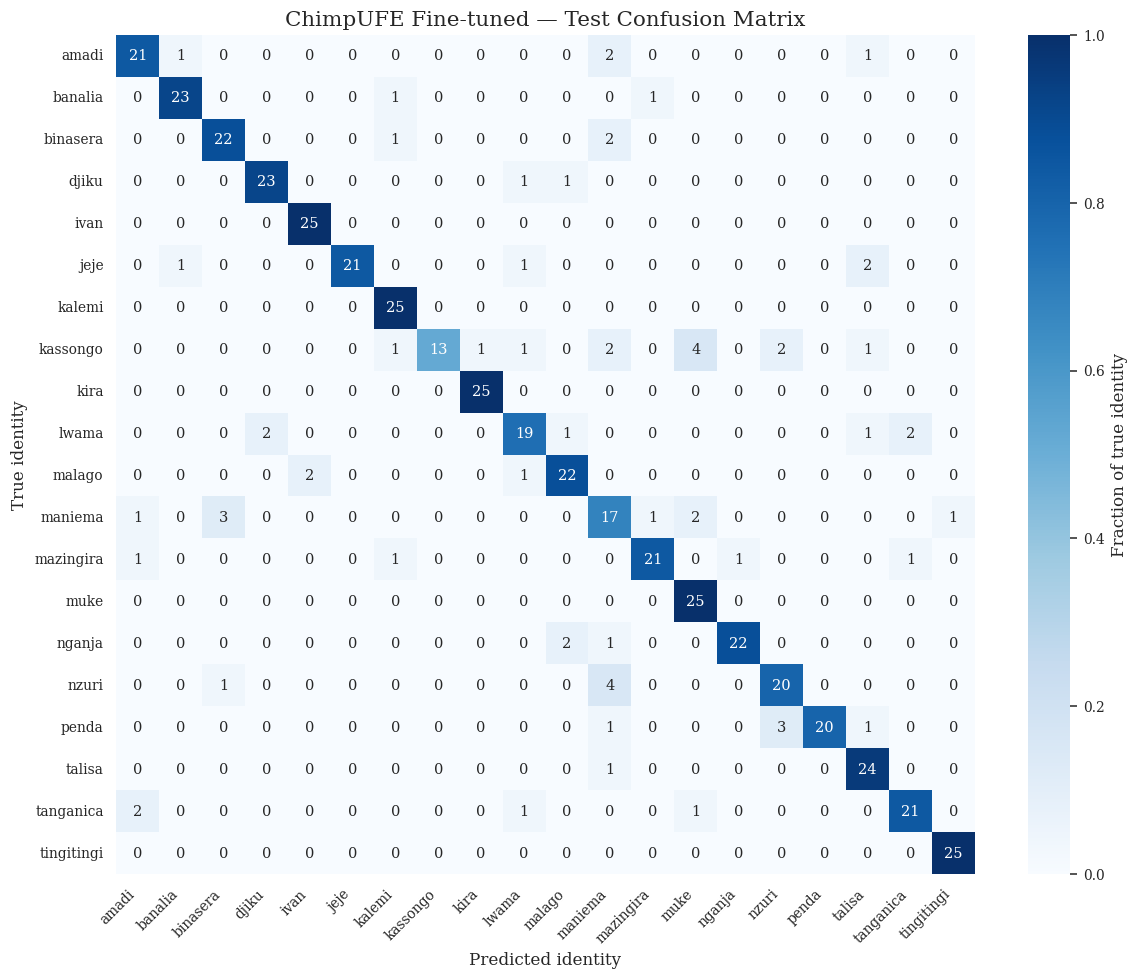

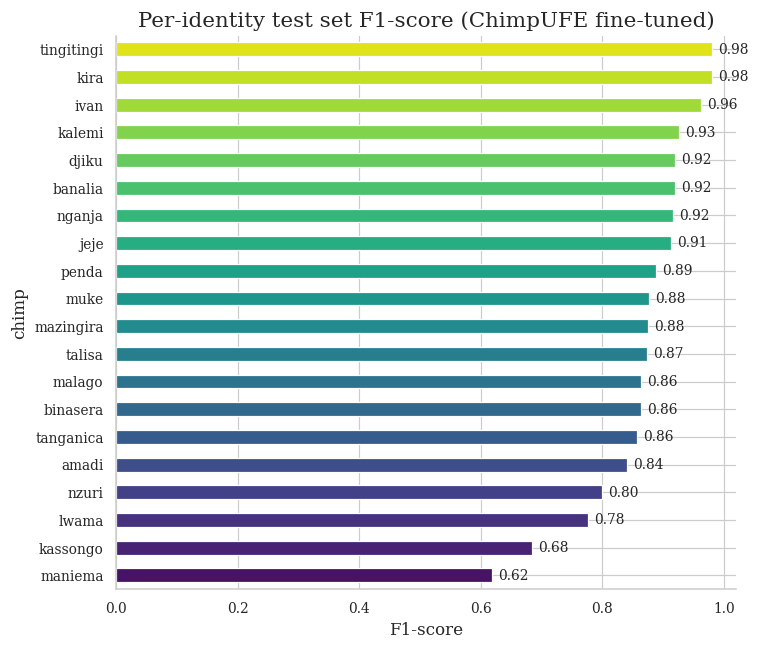

In [11]:
# =============================================================================
# 1b) Test confusion matrix (row-normalized) + per-class F1-score bar
# =============================================================================

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# ------------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------------
cm = confusion_matrix(y_true_idx, pred_top1, labels=list(range(len(idx_to_class))))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df.to_csv(EVAL_OUT_DIR / "test_confusion_matrix.csv")

cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, np.where(cm_row_sum == 0, 1, cm_row_sum))

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    cm_norm,
    annot=cm,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={"label": "Fraction of true identity"},
    vmin=0,
    vmax=1,
    ax=ax,
)

ax.set_xlabel("Predicted identity")
ax.set_ylabel("True identity")
ax.set_title("ChimpUFE Fine-tuned — Test Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(EVAL_OUT_DIR / "test_confusion_matrix.png", dpi=200)
plt.show()


# ------------------------------------------------------------------
# Per-identity precision / recall / F1
# ------------------------------------------------------------------
precision_per_class, recall_per_class, f1_per_class, support_per_class = (
    precision_recall_fscore_support(
        y_true_idx,
        pred_top1,
        labels=list(range(len(idx_to_class))),
        zero_division=0,
    )
)

per_class_metrics = pd.DataFrame({
    "chimp": target_names,
    "precision": precision_per_class,
    "recall": recall_per_class,
    "f1": f1_per_class,
    "support": support_per_class,
})

per_class_metrics.to_csv(
    EVAL_OUT_DIR / "test_per_class_precision_recall_f1.csv",
    index=False,
)

# Sort by F1-score
f1_series = per_class_metrics.set_index("chimp")["f1"].sort_values()


# ------------------------------------------------------------------
# Per-identity F1-score bar plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

f1_series.plot(
    kind="barh",
    ax=ax,
    color=sns.color_palette("viridis", len(f1_series)),
)

ax.set_xlim(0, 1.02)
ax.set_xlabel("F1-score")
ax.set_title("Per-identity test set F1-score (ChimpUFE fine-tuned)")

for i, v in enumerate(f1_series.values):
    ax.text(
        min(v + 0.01, 1.0),
        i,
        f"{v:.2f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()

plt.savefig(EVAL_OUT_DIR / "test_per_class_f1_score.png", dpi=300)
plt.show()

Raw df_perf columns: ['Unnamed: 0', 'precision', 'recall', 'f1-score', 'support']
Raw df_counts columns: ['chimp', 'tier1_train', 'tier1_val', 'tier2_train', 'tier2_val', 'tier3_train', 'train_total', 'val_total']

Cleaned df_perf identities:
['amadi', 'banalia', 'binasera', 'djiku', 'ivan', 'jeje', 'kalemi', 'kassongo', 'kira', 'lwama', 'malago', 'maniema', 'mazingira', 'muke', 'nganja', 'nzuri', 'penda', 'talisa', 'tanganica', 'tingitingi']

Counts identities:
['amadi', 'banalia', 'binasera', 'djiku', 'ivan', 'jeje', 'kalemi', 'kassongo', 'kira', 'lwama', 'malago', 'maniema', 'mazingira', 'muke', 'nganja', 'nzuri', 'penda', 'talisa', 'tanganica', 'tingitingi']

In counts but not performance:
[]

In performance but not counts:
[]

Number of merged identities: 20

Correlation between training data availability and per-identity F1-score:


,data_feature,spearman_rho,spearman_p
2,Tier~1 train images,-0.073,0.759
5,Tier~2 train images,0.025,0.916
8,Tier~3 train images,0.339,0.144
14,Total train images,0.329,0.157



LaTeX rows for F1 correlation table:
Tier~1 train images & -0.073 & 0.759 \\
Tier~2 train images & 0.025 & 0.916 \\
Tier~3 train images & 0.339 & 0.144 \\
Total train images & 0.329 & 0.157 \\

Linear regression: F1 ~ log(total training images)
  slope     = 0.0227
  intercept = 0.7188
  R²        = 0.050

Linear regression: recall ~ log(total training images)
  slope     = 0.0227
  intercept = 0.7188
  R²        = 0.050

Worst identities by F1-score:


,chimp,tier1_train,tier2_train,tier3_train,manual_train,train_total,tier3_share_train,precision_clf,recall_clf,f1_clf,support,test_correct,f1_pred_from_log_total,f1_residual,difficulty_given_data
13,maniema,44,15,354,59,413,0.857,0.567,0.680,0.618,25.000000,17,0.855,-0.237,harder_than_expected
10,kassongo,31,20,579,51,630,0.919,1.000,0.520,0.684,25.000000,13,0.865,-0.181,harder_than_expected
15,lwama,49,7,313,56,369,0.848,0.792,0.760,0.776,25.000000,19,0.853,-0.077,as_expected
12,nzuri,44,20,458,64,522,0.877,0.800,0.800,0.800,25.000000,20,0.861,-0.061,as_expected
9,amadi,56,21,831,77,908,0.915,0.840,0.840,0.840,25.000000,21,0.873,-0.033,as_expected
18,tanganica,42,41,47,83,130,0.362,0.875,0.840,0.857,25.000000,21,0.829,0.028,as_expected



Harder than expected given data:


,chimp,tier1_train,tier2_train,tier3_train,manual_train,train_total,tier3_share_train,precision_clf,recall_clf,f1_clf,support,test_correct,f1_pred_from_log_total,f1_residual,difficulty_given_data
13,maniema,44,15,354,59,413,0.857,0.567,0.680,0.618,25.000000,17,0.855,-0.237,harder_than_expected
10,kassongo,31,20,579,51,630,0.919,1.000,0.520,0.684,25.000000,13,0.865,-0.181,harder_than_expected
15,lwama,49,7,313,56,369,0.848,0.792,0.760,0.776,25.000000,19,0.853,-0.077,as_expected
12,nzuri,44,20,458,64,522,0.877,0.800,0.800,0.800,25.000000,20,0.861,-0.061,as_expected
0,binasera,44,46,3691,90,3781,0.976,0.846,0.880,0.863,25.000000,22,0.906,-0.043,as_expected
9,amadi,56,21,831,77,908,0.915,0.840,0.840,0.840,25.000000,21,0.873,-0.033,as_expected



Easier than expected given data:


,chimp,tier1_train,tier2_train,tier3_train,manual_train,train_total,tier3_share_train,precision_clf,recall_clf,f1_clf,support,test_correct,f1_pred_from_log_total,f1_residual,difficulty_given_data
14,ivan,51,2,353,53,406,0.869,0.926,1.000,0.962,25.000000,25,0.855,0.106,easier_than_expected
4,kira,43,42,959,85,1044,0.919,0.962,1.000,0.980,25.000000,25,0.876,0.104,easier_than_expected
2,tingitingi,38,42,1778,80,1858,0.957,0.962,1.000,0.980,25.000000,25,0.890,0.091,as_expected
16,djiku,49,3,246,52,298,0.826,0.920,0.920,0.920,25.000000,23,0.848,0.072,as_expected
17,jeje,36,18,234,54,288,0.812,1.000,0.840,0.913,25.000000,21,0.847,0.066,as_expected
11,nganja,33,13,581,46,627,0.927,0.957,0.880,0.917,25.000000,22,0.865,0.052,as_expected


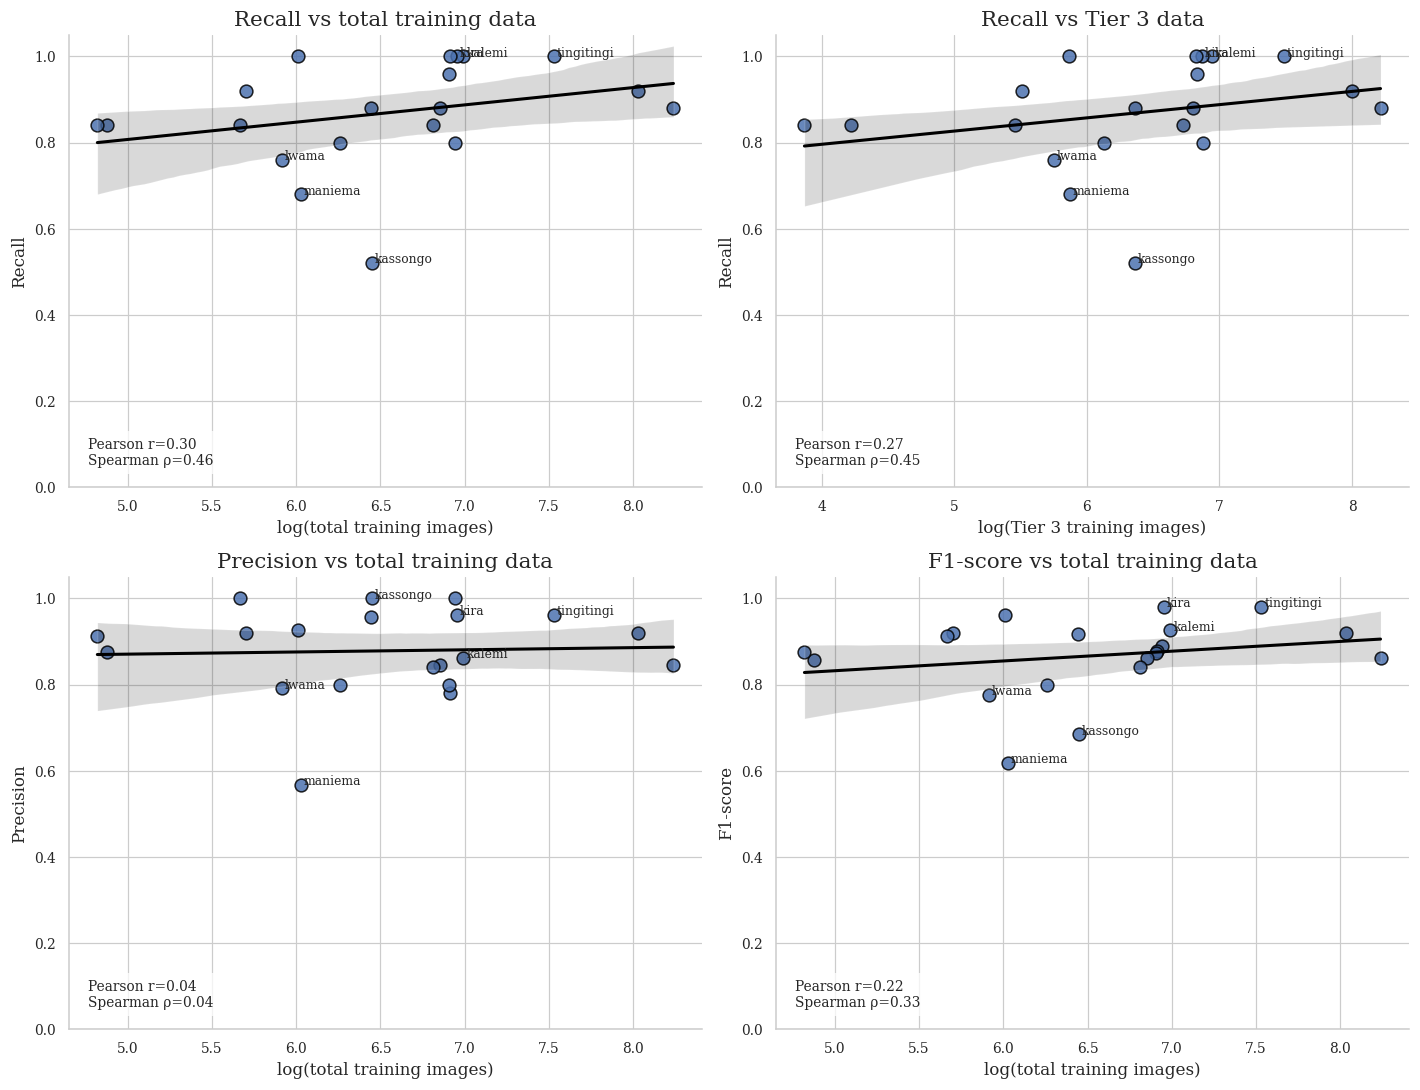

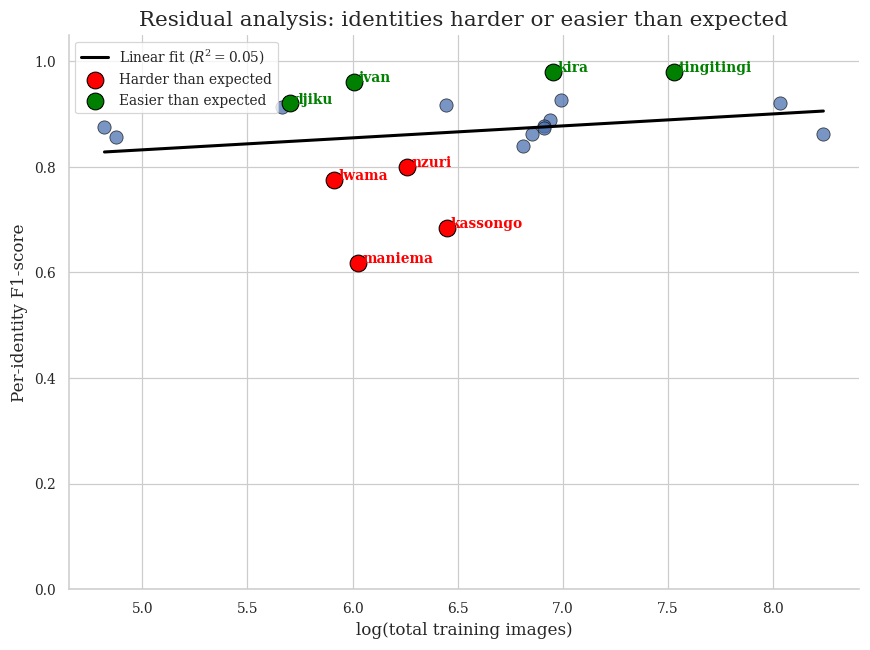

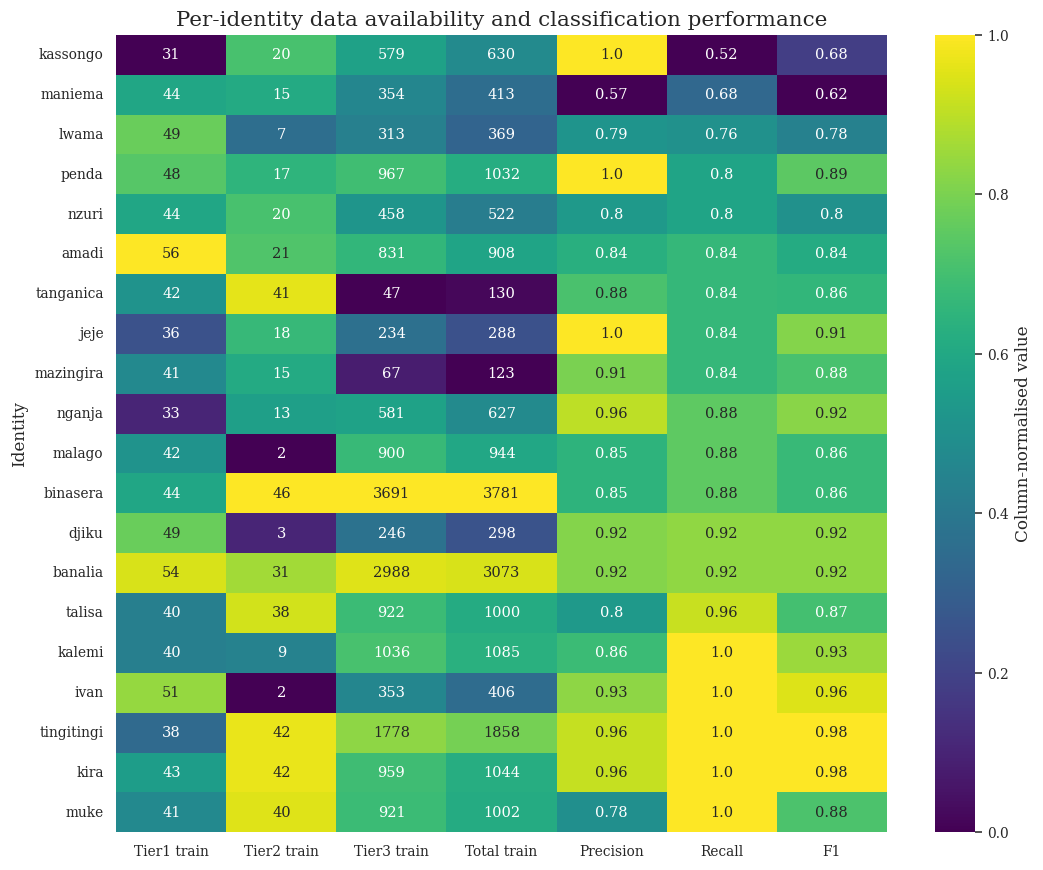

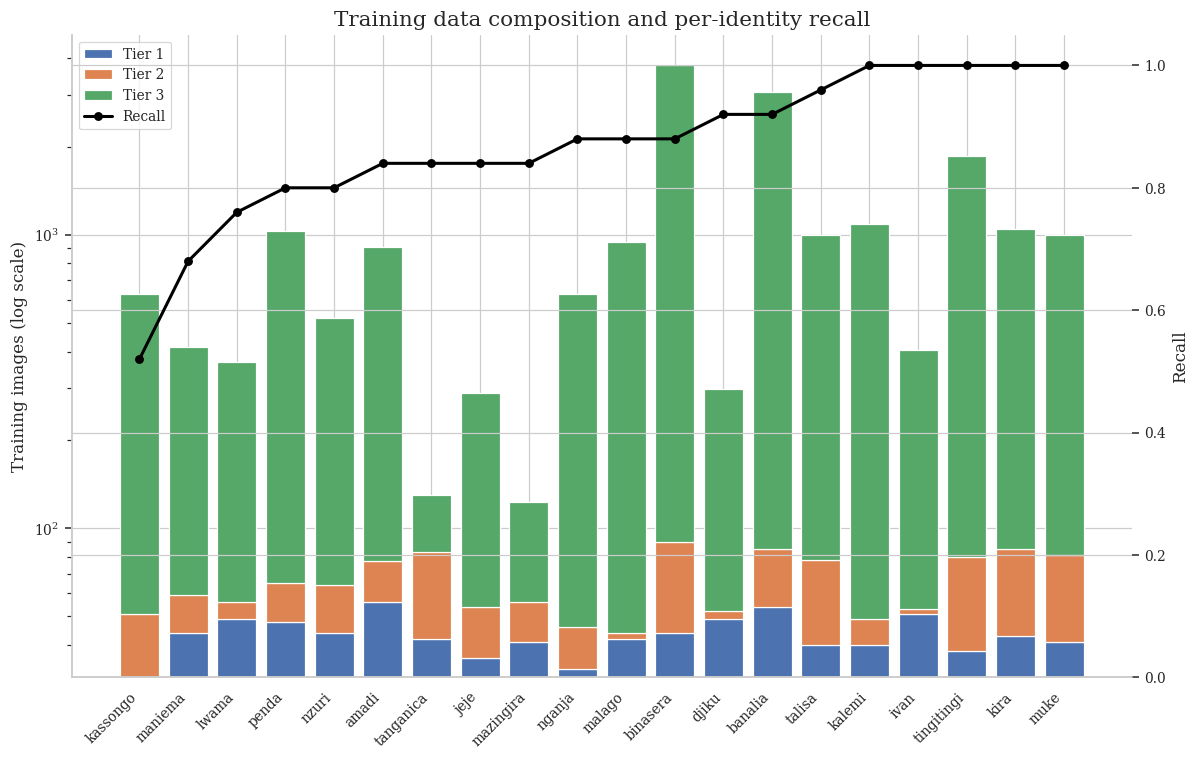


Saved outputs:
  - /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/data_performance_correlation_table.csv
  - /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/per_identity_data_vs_performance_analysis.csv
  - /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/data_performance_correlation_overview.png
  - /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/data_performance_residual_analysis.png
  - /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/data_performance_identity_heatmap.png
  - /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/tier_composition_vs_recall.png


In [12]:
 
# =============================================================================
# 0) PATHS
# =============================================================================

path_report = Path(
    "./test_eval_chimpufe_ft_t3_frontal55/test_classification_report.csv"
)

path_counts = Path(
    "../data_engine/results/tables/per_class_counts.csv"
)


# =============================================================================
# 1) LOAD AND CLEAN TABLES
# =============================================================================

df_perf = pd.read_csv(path_report)
df_counts = pd.read_csv(path_counts)

print("Raw df_perf columns:", df_perf.columns.tolist())
print("Raw df_counts columns:", df_counts.columns.tolist())

# ------------------------------------------------------------------
# Recover chimp names from sklearn classification_report CSV
# ------------------------------------------------------------------
# Case 1: chimp column already exists
if "chimp" in df_perf.columns:
    pass

# Case 2: class names were saved as an unnamed first column
elif "Unnamed: 0" in df_perf.columns:
    df_perf = df_perf.rename(columns={"Unnamed: 0": "chimp"})

# Case 3: first column contains class names but has another name
else:
    first_col = df_perf.columns[0]
    df_perf = df_perf.rename(columns={first_col: "chimp"})

# ------------------------------------------------------------------
# Clean identity names
# ------------------------------------------------------------------
df_perf["chimp"] = df_perf["chimp"].astype(str).str.strip().str.lower()
df_counts["chimp"] = df_counts["chimp"].astype(str).str.strip().str.lower()

# ------------------------------------------------------------------
# Remove sklearn summary rows
# ------------------------------------------------------------------
summary_rows = ["accuracy", "macro avg", "weighted avg"]
df_perf = df_perf[~df_perf["chimp"].isin(summary_rows)].copy()

# ------------------------------------------------------------------
# Keep required columns only
# ------------------------------------------------------------------
required_cols = ["chimp", "precision", "recall", "f1-score", "support"]

missing_cols = [c for c in required_cols if c not in df_perf.columns]
if missing_cols:
    raise ValueError(f"Missing columns in classification report: {missing_cols}")

df_perf = df_perf[required_cols].copy()

# ------------------------------------------------------------------
# Numeric conversion
# ------------------------------------------------------------------
for col in ["precision", "recall", "f1-score", "support"]:
    df_perf[col] = pd.to_numeric(df_perf[col], errors="coerce")

df_perf = df_perf.dropna(subset=["precision", "recall", "f1-score"])

# ------------------------------------------------------------------
# Rename metrics for clarity
# ------------------------------------------------------------------
df_perf = df_perf.rename(columns={
    "precision": "precision_clf",
    "recall": "recall_clf",
    "f1-score": "f1_clf",
})

# ------------------------------------------------------------------
# Debug before merge
# ------------------------------------------------------------------
print("\nCleaned df_perf identities:")
print(sorted(df_perf["chimp"].unique()))

print("\nCounts identities:")
print(sorted(df_counts["chimp"].unique()))

print("\nIn counts but not performance:")
print(sorted(set(df_counts["chimp"]) - set(df_perf["chimp"])))

print("\nIn performance but not counts:")
print(sorted(set(df_perf["chimp"]) - set(df_counts["chimp"])))

# ------------------------------------------------------------------
# Merge
# ------------------------------------------------------------------
df = df_counts.merge(df_perf, on="chimp", how="inner")

print(f"\nNumber of merged identities: {len(df)}")

if len(df) != 20:
    raise ValueError(
        f"Merge produced {len(df)} identities instead of 20. "
        "Check mismatched chimp names printed above."
    )


# =============================================================================
# 2) DERIVED DATA FEATURES
# =============================================================================

df["tier1_total"] = df["tier1_train"] + df["tier1_val"]
df["tier2_total"] = df["tier2_train"] + df["tier2_val"]
df["tier3_total"] = df["tier3_train"]

df["manual_train"] = df["tier1_train"] + df["tier2_train"]
df["manual_total"] = df["tier1_total"] + df["tier2_total"]

# Ratios
df["tier3_share_train"] = df["tier3_train"] / df["train_total"]
df["tier1_share_train"] = df["tier1_train"] / df["train_total"]
df["manual_share_train"] = df["manual_train"] / df["train_total"]

# Log transforms: useful because Tier 3 varies by orders of magnitude
df["log_tier1_train"] = np.log1p(df["tier1_train"])
df["log_tier2_train"] = np.log1p(df["tier2_train"])
df["log_tier3_train"] = np.log1p(df["tier3_train"])
df["log_manual_train"] = np.log1p(df["manual_train"])
df["log_train_total"] = np.log1p(df["train_total"])

# Since the test set is balanced, recall is per-identity top-1 recall
df["test_correct"] = df["recall_clf"] * df["support"]


# =============================================================================
# 3) CORRELATION TABLE
# =============================================================================

def corr_pair(x, y):
    """
    Return Pearson r, Pearson p-value, Spearman rho, Spearman p-value.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    return pearson_r, pearson_p, spearman_r, spearman_p


data_features = [
    "tier1_train",
    "tier2_train",
    "tier3_train",
    "manual_train",
    "train_total",
    "log_tier1_train",
    "log_tier2_train",
    "log_tier3_train",
    "log_manual_train",
    "log_train_total",
    "tier3_share_train",
    "tier1_share_train",
    "manual_share_train",
]

performance_metrics = [
    "precision_clf",
    "recall_clf",
    "f1_clf",
]

rows = []

for data_col in data_features:
    for metric_col in performance_metrics:
        pearson_r, pearson_p, spearman_r, spearman_p = corr_pair(
            df[data_col],
            df[metric_col],
        )

        rows.append({
            "data_feature": data_col,
            "performance_metric": metric_col,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_r,
            "spearman_p": spearman_p,
        })

corr_table = pd.DataFrame(rows)

corr_table.to_csv(
    EVAL_OUT_DIR / "data_performance_correlation_table.csv",
    index=False,
)


# ------------------------------------------------------------------
# F1 correlation table for thesis
# ------------------------------------------------------------------

f1_features = [
    "tier1_train",
    "tier2_train",
    "tier3_train",
    "train_total",
]

feature_names = {
    "tier1_train": "Tier~1 train images",
    "tier2_train": "Tier~2 train images",
    "tier3_train": "Tier~3 train images",
    "train_total": "Total train images",
}

f1_corr = (
    corr_table[
        (corr_table["performance_metric"] == "f1_clf")
        & (corr_table["data_feature"].isin(f1_features))
    ]
    .copy()
)

# Keep the same order as in the thesis table
f1_corr["order"] = f1_corr["data_feature"].map({
    "tier1_train": 1,
    "tier2_train": 2,
    "tier3_train": 3,
    "train_total": 4,
})

f1_corr = f1_corr.sort_values("order")

f1_corr_display = f1_corr[[
    "data_feature",
    "spearman_rho",
    "spearman_p",
]].copy()

f1_corr_display["data_feature"] = f1_corr_display["data_feature"].map(feature_names)

print("\nCorrelation between training data availability and per-identity F1-score:")
display(
    f1_corr_display.style.format({
        "spearman_rho": "{:.3f}",
        "spearman_p": "{:.3f}",
    })
)

# Save compact F1 table
f1_corr_display.to_csv(
    EVAL_OUT_DIR / "data_f1_correlation_table_for_thesis.csv",
    index=False,
)

# Optional: print LaTeX rows directly
print("\nLaTeX rows for F1 correlation table:")
for _, row in f1_corr_display.iterrows():
    print(
        f"{row['data_feature']} & "
        f"{row['spearman_rho']:.3f} & "
        f"{row['spearman_p']:.3f} \\\\"
    )




#=============================================================================
# REGRESSION / RESIDUAL ANALYSIS BASED ON F1
# =============================================================================

# Main explanatory variable: log total training images
x = df[["log_train_total"]].values
y = df["f1_clf"].values

reg = LinearRegression()
reg.fit(x, y)

df["f1_pred_from_log_total"] = reg.predict(x)
df["f1_residual"] = df["f1_clf"] - df["f1_pred_from_log_total"]

r2 = r2_score(y, df["f1_pred_from_log_total"])

print("\nLinear regression: F1 ~ log(total training images)")
print(f"  slope     = {reg.coef_[0]:.4f}")
print(f"  intercept = {reg.intercept_:.4f}")
print(f"  R²        = {r2:.3f}")

# Easier / harder than expected
df["difficulty_given_data"] = pd.cut(
    df["f1_residual"],
    bins=[-np.inf, -0.10, 0.10, np.inf],
    labels=["harder_than_expected", "as_expected", "easier_than_expected"],
)


print("\nLinear regression: recall ~ log(total training images)")
print(f"  slope     = {reg.coef_[0]:.4f}")
print(f"  intercept = {reg.intercept_:.4f}")
print(f"  R²        = {r2:.3f}")

# Easier / harder than expected
df["difficulty_given_data"] = pd.cut(
    df["f1_residual"],
    bins=[-np.inf, -0.10, 0.10, np.inf],
    labels=["harder_than_expected", "as_expected", "easier_than_expected"],
)

# Save detailed table
analysis_cols = [
    "chimp",
    "tier1_train",
    "tier2_train",
    "tier3_train",
    "manual_train",
    "train_total",
    "tier3_share_train",
    "precision_clf",
    "recall_clf",
    "f1_clf",
    "support",
    "test_correct",
    "f1_pred_from_log_total",
    "f1_residual",
    "difficulty_given_data",
]

df_analysis = df[analysis_cols].sort_values("f1_clf")

df_analysis.to_csv(
    EVAL_OUT_DIR / "per_identity_data_vs_performance_analysis.csv",
    index=False,
)

print("\nWorst identities by F1-score:")
display(
    df_analysis.head(6).style.format({
        "precision_clf": "{:.3f}",
        "recall_clf": "{:.3f}",
        "f1_clf": "{:.3f}",
        "tier3_share_train": "{:.3f}",
        "test_correct": "{:.0f}",
        "f1_pred_from_log_total": "{:.3f}",
        "f1_residual": "{:.3f}",
    })
)

print("\nHarder than expected given data:")
display(
    df_analysis.sort_values("f1_residual").head(6).style.format({
        "precision_clf": "{:.3f}",
        "recall_clf": "{:.3f}",
        "f1_clf": "{:.3f}",
        "tier3_share_train": "{:.3f}",
        "test_correct": "{:.0f}",
        "f1_pred_from_log_total": "{:.3f}",
        "f1_residual": "{:.3f}",
    })
)

print("\nEasier than expected given data:")
display(
    df_analysis.sort_values("f1_residual", ascending=False).head(6).style.format({
        "precision_clf": "{:.3f}",
        "recall_clf": "{:.3f}",
        "f1_clf": "{:.3f}",
        "tier3_share_train": "{:.3f}",
        "test_correct": "{:.0f}",
        "f1_pred_from_log_total": "{:.3f}",
        "f1_residual": "{:.3f}",
    })
)


# =============================================================================
# 5) FIGURE A: 2x2 CORRELATION OVERVIEW
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plots = [
    (
        "log_train_total",
        "recall_clf",
        "log(total training images)",
        "Recall",
        "Recall vs total training data",
    ),
    (
        "log_tier3_train",
        "recall_clf",
        "log(Tier 3 training images)",
        "Recall",
        "Recall vs Tier 3 data",
    ),
    (
        "log_train_total",
        "precision_clf",
        "log(total training images)",
        "Precision",
        "Precision vs total training data",
    ),
    (
        "log_train_total",
        "f1_clf",
        "log(total training images)",
        "F1-score",
        "F1-score vs total training data",
    ),
]

for ax, (x_col, y_col, xlabel, ylabel, title) in zip(axes.ravel(), plots):

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        ax=ax,
        scatter_kws={
            "s": 70,
            "alpha": 0.85,
            "edgecolors": "black",
        },
        line_kws={
            "color": "black",
            "linewidth": 2,
        },
    )

    # Annotate most important cases only: worst recall and best recall
    important = pd.concat([
        df.nsmallest(3, "recall_clf"),
        df.nlargest(3, "recall_clf"),
    ]).drop_duplicates(subset="chimp")

    for _, row in important.iterrows():
        ax.text(
            row[x_col] + 0.02,
            row[y_col],
            row["chimp"],
            fontsize=8,
        )

    # Add correlation value in the corner
    pr, pp, sr, sp = corr_pair(df[x_col], df[y_col])

    ax.text(
        0.03,
        0.05,
        f"Pearson r={pr:.2f}\nSpearman ρ={sr:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none",
        ),
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    EVAL_OUT_DIR / "data_performance_correlation_overview.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()



#============================================================================
# FIGURE B: F1 RESIDUAL ANALYSIS
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Main scatter
ax.scatter(
    df["log_train_total"],
    df["f1_clf"],
    s=75,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.5,
)

# Regression line
x_line = np.linspace(
    df["log_train_total"].min(),
    df["log_train_total"].max(),
    200,
)

y_line = reg.predict(x_line.reshape(-1, 1))

ax.plot(
    x_line,
    y_line,
    color="black",
    linewidth=2,
    label=f"Linear fit ($R^2={r2:.2f}$)",
)

# Highlight residual extremes
hard = df.nsmallest(4, "f1_residual")
easy = df.nlargest(4, "f1_residual")

ax.scatter(
    hard["log_train_total"],
    hard["f1_clf"],
    color="red",
    s=120,
    edgecolors="black",
    linewidths=0.7,
    label="Harder than expected",
)

ax.scatter(
    easy["log_train_total"],
    easy["f1_clf"],
    color="green",
    s=120,
    edgecolors="black",
    linewidths=0.7,
    label="Easier than expected",
)

for _, row in hard.iterrows():
    ax.text(
        row["log_train_total"] + 0.02,
        row["f1_clf"],
        row["chimp"],
        fontsize=9,
        color="red",
        weight="bold",
    )

for _, row in easy.iterrows():
    ax.text(
        row["log_train_total"] + 0.02,
        row["f1_clf"],
        row["chimp"],
        fontsize=9,
        color="green",
        weight="bold",
    )

ax.set_xlabel("log(total training images)")
ax.set_ylabel("Per-identity F1-score")
ax.set_title("Residual analysis: identities harder or easier than expected")
ax.set_ylim(0, 1.05)
ax.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    EVAL_OUT_DIR / "data_performance_f1_residual_analysis.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()



# =============================================================================
# 7) FIGURE C: PERFORMANCE + DATA TABLE AS HEATMAP
# =============================================================================

heat_df = df.copy()
heat_df = heat_df.sort_values("recall_clf")

heat_cols = [
    "tier1_train",
    "tier2_train",
    "tier3_train",
    "train_total",
    "precision_clf",
    "recall_clf",
    "f1_clf",
]

# Normalise columns for heatmap visual comparison
heat_norm = heat_df[heat_cols].copy()

for col in ["tier1_train", "tier2_train", "tier3_train", "train_total"]:
    heat_norm[col] = np.log1p(heat_norm[col])

heat_norm = (heat_norm - heat_norm.min()) / (heat_norm.max() - heat_norm.min())

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    heat_norm,
    annot=heat_df[heat_cols].round(2).astype(str).values,
    fmt="",
    cmap="viridis",
    yticklabels=heat_df["chimp"],
    xticklabels=[
        "Tier1 train",
        "Tier2 train",
        "Tier3 train",
        "Total train",
        "Precision",
        "Recall",
        "F1",
    ],
    cbar_kws={"label": "Column-normalised value"},
    ax=ax,
)

ax.set_title("Per-identity data availability and classification performance")
ax.set_xlabel("")
ax.set_ylabel("Identity")

plt.tight_layout()

plt.savefig(
    EVAL_OUT_DIR / "data_performance_identity_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# 8) FIGURE D: TIER COMPOSITION + RECALL
# =============================================================================

df_bar = df.sort_values("recall_clf")

fig, ax1 = plt.subplots(figsize=(11, 7))

x_pos = np.arange(len(df_bar))

# Stacked bars for training data composition
ax1.bar(
    x_pos,
    df_bar["tier1_train"],
    label="Tier 1",
)

ax1.bar(
    x_pos,
    df_bar["tier2_train"],
    bottom=df_bar["tier1_train"],
    label="Tier 2",
)

ax1.bar(
    x_pos,
    df_bar["tier3_train"],
    bottom=df_bar["tier1_train"] + df_bar["tier2_train"],
    label="Tier 3",
)

ax1.set_yscale("log")
ax1.set_ylabel("Training images (log scale)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_bar["chimp"], rotation=45, ha="right")
ax1.set_title("Training data composition and per-identity recall")

# Recall line on second axis
ax2 = ax1.twinx()

ax2.plot(
    x_pos,
    df_bar["recall_clf"],
    color="black",
    marker="o",
    linewidth=2,
    label="Recall",
)

ax2.set_ylabel("Recall")
ax2.set_ylim(0, 1.05)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    EVAL_OUT_DIR / "tier_composition_vs_recall.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# 9) FINAL SUMMARY
# =============================================================================

print("\nSaved outputs:")
print(f"  - {EVAL_OUT_DIR / 'data_performance_correlation_table.csv'}")
print(f"  - {EVAL_OUT_DIR / 'per_identity_data_vs_performance_analysis.csv'}")
print(f"  - {EVAL_OUT_DIR / 'data_performance_correlation_overview.png'}")
print(f"  - {EVAL_OUT_DIR / 'data_performance_residual_analysis.png'}")
print(f"  - {EVAL_OUT_DIR / 'data_performance_identity_heatmap.png'}")
print(f"  - {EVAL_OUT_DIR / 'tier_composition_vs_recall.png'}")

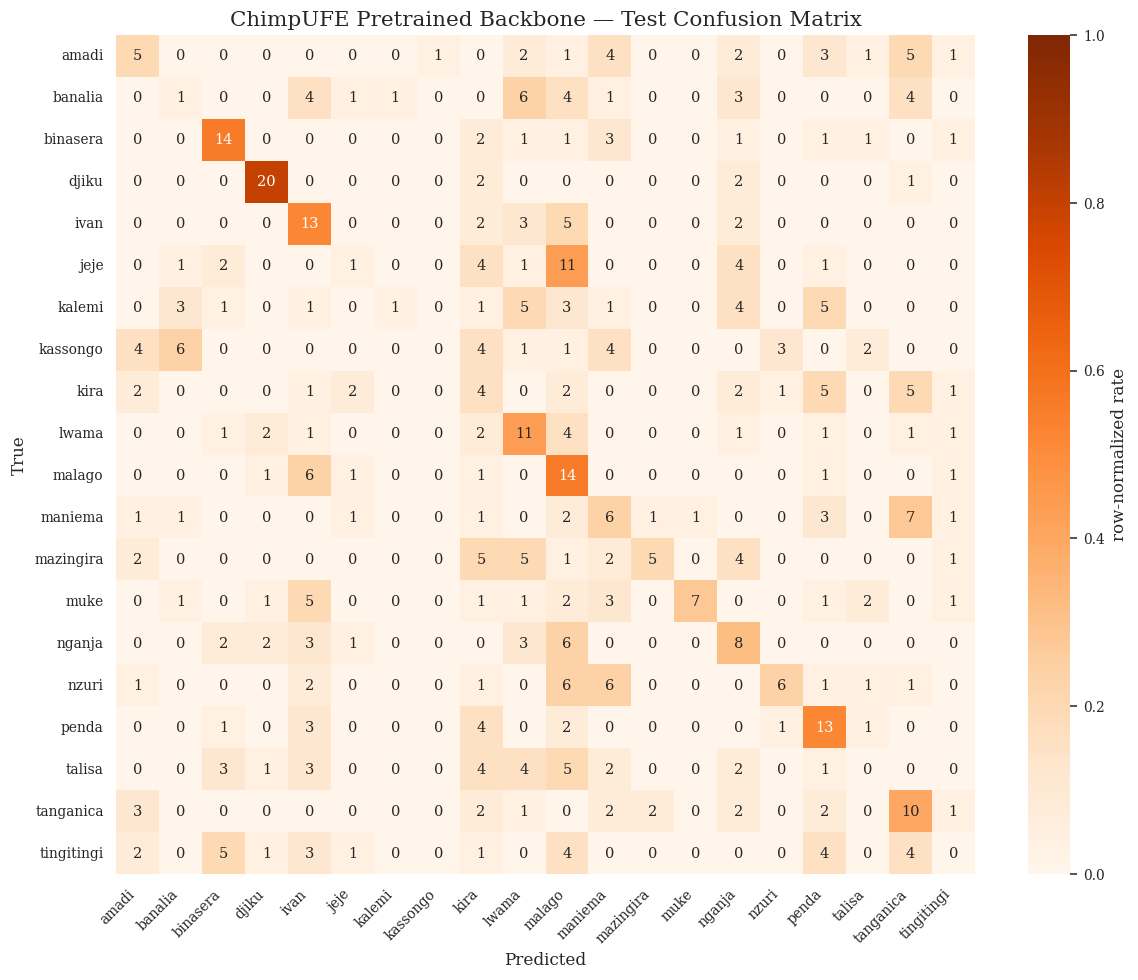

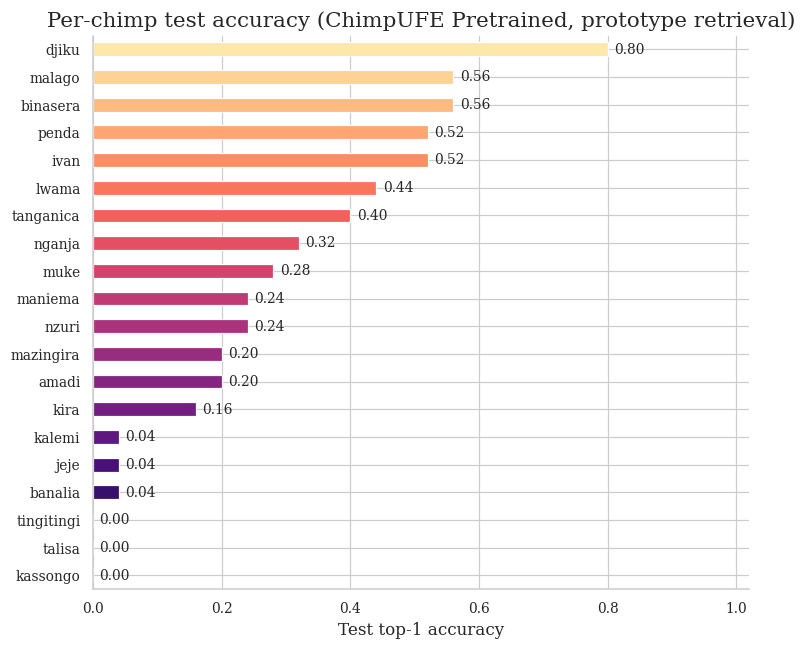

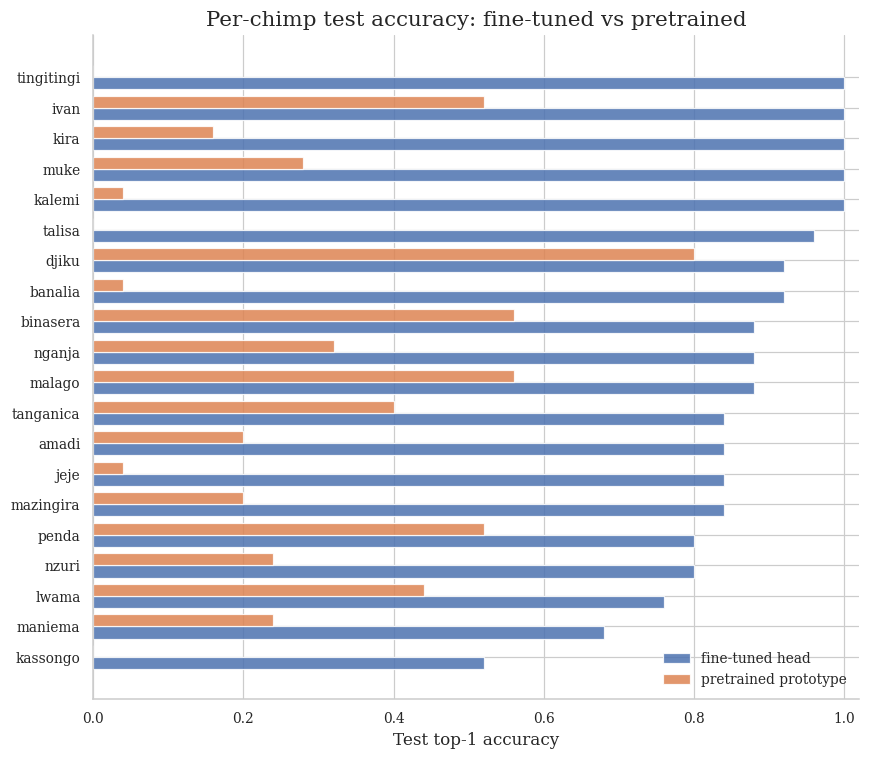

In [13]:
# =============================================================================
# 1c) Pretrained model confusion matrix + per-class accuracy (prototype retrieval)
#     The pretrained backbone has no classifier head, so we use prototype
#     predictions (gallery=train, query=test) computed inline here.
# =============================================================================
def _class_prototypes(emb, labels, class_order):
    protos, used = [], []
    for c in class_order:
        idx = [i for i, l in enumerate(labels) if l == c]
        if not idx:
            continue
        v = emb[idx].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v); used.append(c)
    return np.stack(protos, axis=0).astype(np.float32), used

_pt_protos, _pt_proto_names = _class_prototypes(pt_train_emb, pt_train_labels, CANONICAL_NAMES)
_pt_sim = pt_test_emb @ _pt_protos.T
_pt_pred_proto = [_pt_proto_names[k] for k in np.argmax(_pt_sim, axis=1)]

pt_pred_idx = np.array([class_to_idx[p] for p in _pt_pred_proto])
pt_true_idx = np.array([class_to_idx[l] for l in pt_test_labels])

cm_pt = confusion_matrix(pt_true_idx, pt_pred_idx, labels=list(range(len(idx_to_class))))
cm_pt_df = pd.DataFrame(cm_pt, index=target_names, columns=target_names)
cm_pt_df.to_csv(EVAL_OUT_DIR / "test_confusion_matrix_pretrained.csv")

cm_pt_row_sum = cm_pt.sum(axis=1, keepdims=True)
cm_pt_norm = np.divide(cm_pt, np.where(cm_pt_row_sum == 0, 1, cm_pt_row_sum))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_pt_norm, annot=cm_pt, fmt="d", cmap="Oranges",
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={"label": "row-normalized rate"}, vmin=0, vmax=1, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("ChimpUFE Pretrained Backbone — Test Confusion Matrix")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_confusion_matrix_pretrained.png", dpi=200)
plt.show()

per_class_acc_pt = {}
for ci, name in idx_to_class.items():
    mask = pt_true_idx == ci
    per_class_acc_pt[name] = float((pt_pred_idx[mask] == ci).mean()) if mask.any() else float("nan")
pca_pt_series = pd.Series(per_class_acc_pt).sort_values()

per_class_acc = {}
for ci, name in idx_to_class.items():
    mask = y_true_idx == ci
    per_class_acc[name] = float((pred_top1[mask] == ci).mean()) if mask.any() else float("nan")

fig, ax = plt.subplots(figsize=(7, 6))
pca_pt_series.plot(kind="barh", ax=ax,
                   color=sns.color_palette("magma", len(pca_pt_series)))
ax.set_xlim(0, 1.02); ax.set_xlabel("Test top-1 accuracy")
ax.set_title("Per-chimp test accuracy (ChimpUFE Pretrained, prototype retrieval)")
for i, v in enumerate(pca_pt_series.values):
    if not np.isnan(v):
        ax.text(min(v + 0.01, 1.0), i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_per_class_accuracy_pretrained.png", dpi=200)
plt.show()

# Side-by-side per-class accuracy comparison (fine-tuned head vs pretrained prototypes)
pca_compare_df = pd.DataFrame({
    "fine_tuned_head": pd.Series(per_class_acc),
    "pretrained_proto": pd.Series(per_class_acc_pt),
}).sort_values("fine_tuned_head")
pca_compare_df["delta"] = pca_compare_df["fine_tuned_head"] - pca_compare_df["pretrained_proto"]
pca_compare_df.to_csv(EVAL_OUT_DIR / "test_per_class_accuracy_compare.csv")

fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(pca_compare_df))
w = 0.4
ax.barh(y - w/2, pca_compare_df["fine_tuned_head"],   w, label="fine-tuned head",      color="C0", alpha=0.85)
ax.barh(y + w/2, pca_compare_df["pretrained_proto"],  w, label="pretrained prototype", color="C1", alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(pca_compare_df.index)
ax.set_xlim(0, 1.02); ax.set_xlabel("Test top-1 accuracy")
ax.set_title("Per-chimp test accuracy: fine-tuned vs pretrained")
ax.legend()
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_per_class_accuracy_compare.png", dpi=200)
plt.show()


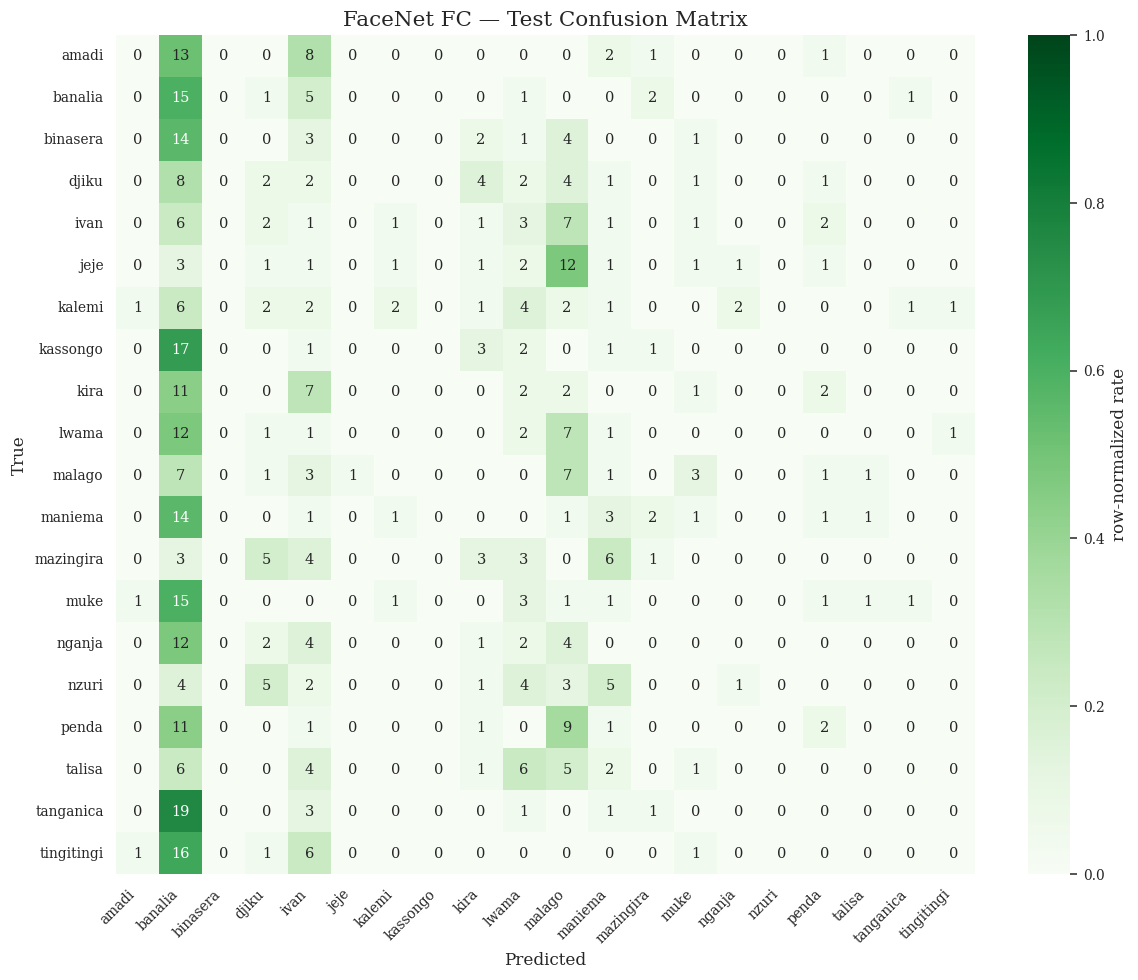

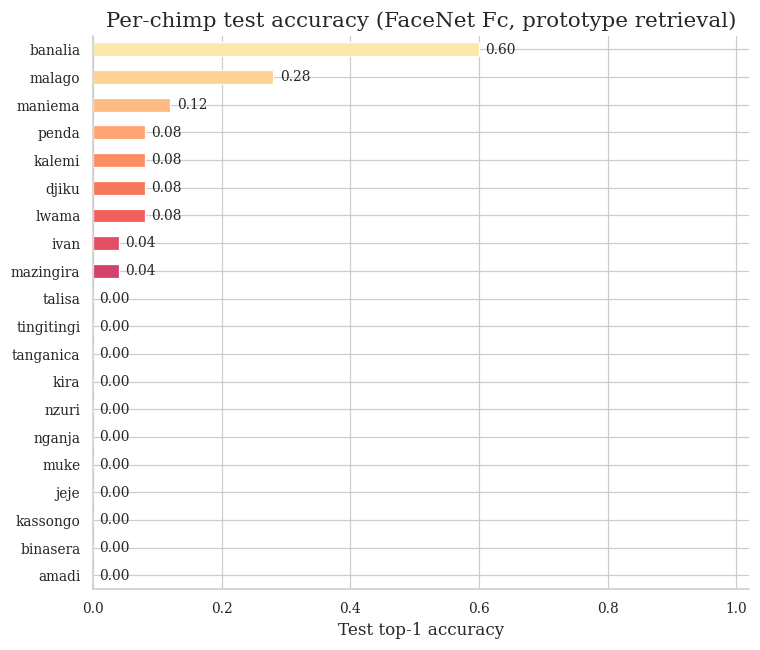

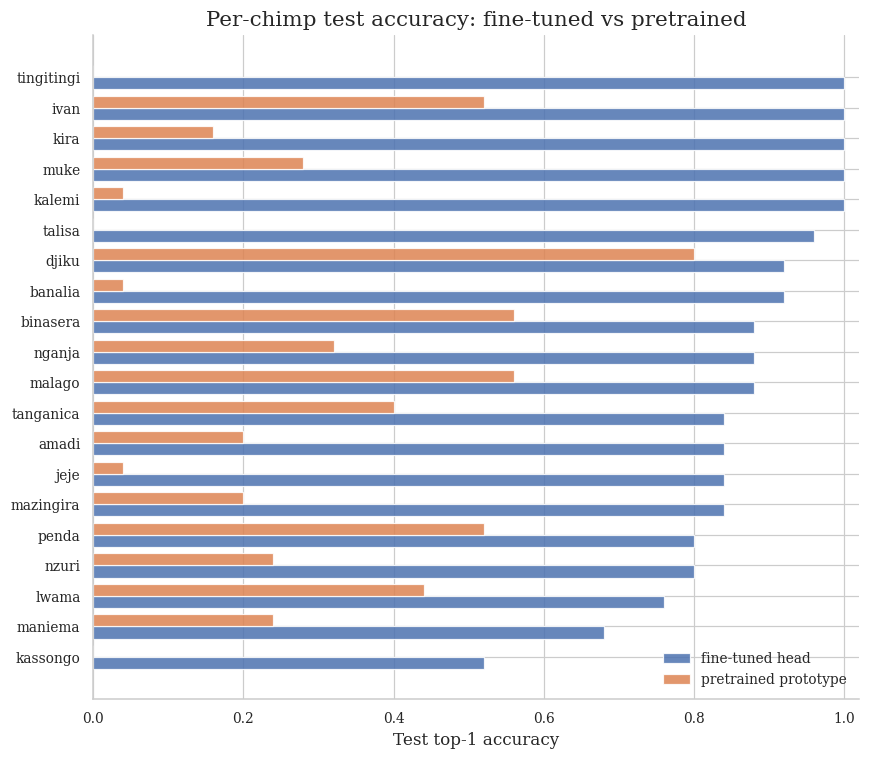

In [14]:
# =============================================================================
# 1d) FaceNet Fc confusion matrix + per-class accuracy (prototype retrieval)
#     The FaceNet Fc has no classifier head, so we use prototype
#     predictions (gallery=train, query=test) computed inline here.
# =============================================================================
def _class_prototypes(emb, labels, class_order):
    protos, used = [], []
    for c in class_order:
        idx = [i for i, l in enumerate(labels) if l == c]
        if not idx:
            continue
        v = emb[idx].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v); used.append(c)
    return np.stack(protos, axis=0).astype(np.float32), used

_fn_protos, _fn_proto_names = _class_prototypes(fn_train_emb, fn_train_labels, CANONICAL_NAMES)
_fn_sim = fn_test_emb @ _fn_protos.T
_fn_pred_proto = [_fn_proto_names[k] for k in np.argmax(_fn_sim, axis=1)]

fn_pred_idx = np.array([class_to_idx[p] for p in _fn_pred_proto])
fn_true_idx = np.array([class_to_idx[l] for l in fn_test_labels])

cm_fn = confusion_matrix(fn_true_idx, fn_pred_idx, labels=list(range(len(idx_to_class))))
cm_fn_df = pd.DataFrame(cm_fn, index=target_names, columns=target_names)
cm_fn_df.to_csv(EVAL_OUT_DIR / "test_confusion_matrix_finetuned.csv")

cm_fn_row_sum = cm_fn.sum(axis=1, keepdims=True)
cm_fn_norm = np.divide(cm_fn, np.where(cm_fn_row_sum == 0, 1, cm_fn_row_sum))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_fn_norm, annot=cm_fn, fmt="d", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={"label": "row-normalized rate"}, vmin=0, vmax=1, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("FaceNet FC — Test Confusion Matrix")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_confusion_matrix_facenetfc.png", dpi=200)
plt.show()

per_class_acc_fn = {}
for ci, name in idx_to_class.items():
    mask = fn_true_idx == ci
    per_class_acc_fn[name] = float((fn_pred_idx[mask] == ci).mean()) if mask.any() else float("nan")
pca_fn_series = pd.Series(per_class_acc_fn).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
pca_fn_series.plot(kind="barh", ax=ax,
                   color=sns.color_palette("magma", len(pca_fn_series)))
ax.set_xlim(0, 1.02); ax.set_xlabel("Test top-1 accuracy")
ax.set_title("Per-chimp test accuracy (FaceNet Fc, prototype retrieval)")
for i, v in enumerate(pca_fn_series.values):
    if not np.isnan(v):
        ax.text(min(v + 0.01, 1.0), i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_per_class_accuracy_facenetfc.png", dpi=200)
plt.show()

# Side-by-side per-class accuracy comparison (fine-tuned head vs pretrained prototypes)
pca_compare_df = pd.DataFrame({
    "fine_tuned_head": pd.Series(per_class_acc),
    "pretrained_proto": pd.Series(per_class_acc_pt),
}).sort_values("fine_tuned_head")
pca_compare_df["delta"] = pca_compare_df["fine_tuned_head"] - pca_compare_df["pretrained_proto"]
pca_compare_df.to_csv(EVAL_OUT_DIR / "test_per_class_accuracy_compare.csv")

fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(pca_compare_df))
w = 0.4
ax.barh(y - w/2, pca_compare_df["fine_tuned_head"],   w, label="fine-tuned head",      color="C0", alpha=0.85)
ax.barh(y + w/2, pca_compare_df["pretrained_proto"],  w, label="pretrained prototype", color="C1", alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(pca_compare_df.index)
ax.set_xlim(0, 1.02); ax.set_xlabel("Test top-1 accuracy")
ax.set_title("Per-chimp test accuracy: fine-tuned vs pretrained")
ax.legend()
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_per_class_accuracy_compare.png", dpi=200)
plt.show()


In [15]:
# =============================================================================
# 2) RETRIEVAL METRICS — leave-one-out within the test set
# =============================================================================
def retrieval_metrics_loo(emb: np.ndarray, labels: list[str]) -> dict:
    n = len(labels); lab = np.array(labels)
    sim = emb @ emb.T
    np.fill_diagonal(sim, -1e9)
    order = np.argsort(-sim, axis=1)
    same  = (lab[order] == lab[:, None]).astype(np.int32)
    top1 = float(same[:, 0].mean())
    top5 = float(np.any(same[:, :5] == 1, axis=1).mean())
    aps = []
    for i in range(n):
        n_pos = int((lab == lab[i]).sum() - 1)
        if n_pos <= 0: continue
        cum = np.cumsum(same[i])
        ranks = np.arange(1, n + 1)
        prec_at_k = cum / ranks
        aps.append(float((prec_at_k * same[i]).sum() / n_pos))
    return {"top1": top1, "top5": top5, "mAP": float(np.mean(aps)) if aps else float("nan"), "n": n}

ft_retr = retrieval_metrics_loo(ft_test_emb, ft_test_labels)
pt_retr = retrieval_metrics_loo(pt_test_emb, pt_test_labels)

retr_df = pd.DataFrame([
    {"model": "fine_tuned_intensive", **ft_retr},
    {"model": "chimpufe_pretrained_340k", **pt_retr},
    {"model": "delta", "top1": ft_retr["top1"]-pt_retr["top1"],
                       "top5": ft_retr["top5"]-pt_retr["top5"],
                       "mAP":  ft_retr["mAP"] -pt_retr["mAP"], "n": ft_retr["n"]},
])
display(retr_df.style.format({"top1":"{:.4f}","top5":"{:.4f}","mAP":"{:.4f}"}))
retr_df.to_csv(EVAL_OUT_DIR / "test_retrieval_metrics_loo.csv", index=False)


,model,top1,top5,mAP,n
0,fine_tuned_intensive,0.9300,0.9560,0.7495,500
1,chimpufe_pretrained_340k,0.7620,0.9060,0.2514,500
2,delta,0.1680,0.0500,0.4981,500


In [16]:
# =============================================================================
# 3) PROTOTYPE RETRIEVAL — train (gallery) -> test (query)
#    This is the realistic deployment setting: enroll using train, query test.
# =============================================================================
def class_prototypes(emb: np.ndarray, labels: list[str], class_order: list[str]) -> tuple[np.ndarray, list[str]]:
    protos = []
    used   = []
    for c in class_order:
        idx = [i for i, l in enumerate(labels) if l == c]
        if not idx:
            continue
        v = emb[idx].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v); used.append(c)
    return np.stack(protos, axis=0).astype(np.float32), used


def proto_eval(query_emb, query_labels, gallery_emb, gallery_labels):
    protos, proto_names = class_prototypes(gallery_emb, gallery_labels, CANONICAL_NAMES)
    sim = query_emb @ protos.T  # cosine since both are L2-normed
    order = np.argsort(-sim, axis=1)
    pred1 = [proto_names[order[i, 0]] for i in range(len(query_labels))]
    top1 = float(np.mean([p == g for p, g in zip(pred1, query_labels)]))
    top5_hits = []
    for i, g in enumerate(query_labels):
        names = [proto_names[k] for k in order[i, :5]]
        top5_hits.append(g in names)
    top5 = float(np.mean(top5_hits))
    # margin = best - second best
    sorted_sims = -np.sort(-sim, axis=1)
    margins = sorted_sims[:, 0] - sorted_sims[:, 1]
    return {"top1": top1, "top5": top5, "margin_mean": float(margins.mean()),
            "margin_std": float(margins.std())}, pred1, sim, proto_names, margins


ft_proto, ft_pred_proto, ft_proto_sim, ft_proto_names, ft_margins = proto_eval(
    ft_test_emb, ft_test_labels, ft_train_emb, ft_train_labels)
pt_proto, pt_pred_proto, pt_proto_sim, pt_proto_names, pt_margins = proto_eval(
    pt_test_emb, pt_test_labels, pt_train_emb, pt_train_labels)
fn_proto, fn_pred_proto, fn_proto_sim, fn_proto_names, fn_margins = proto_eval(
    fn_test_emb, fn_test_labels, fn_train_emb, fn_train_labels)

proto_df = pd.DataFrame([
    {"model": "fine_tuned_intensive", **ft_proto},
    {"model": "chimpufe_pretrained_340k", **pt_proto},
    {"model": "FaceNet-FC", **fn_proto},
    {"model": "delta",
     "top1": ft_proto["top1"]-pt_proto["top1"],
     "top5": ft_proto["top5"]-pt_proto["top5"],
     "margin_mean": ft_proto["margin_mean"]-pt_proto["margin_mean"],
     "margin_std":  ft_proto["margin_std"] -pt_proto["margin_std"]},
])
print("Prototype retrieval (gallery=train, query=test)")
display(proto_df.style.format({"top1":"{:.4f}","top5":"{:.4f}",
                               "margin_mean":"{:.3f}","margin_std":"{:.3f}"}))
proto_df.to_csv(EVAL_OUT_DIR / "test_retrieval_metrics_prototype.csv", index=False)


Prototype retrieval (gallery=train, query=test)


,model,top1,top5,margin_mean,margin_std
0,fine_tuned_intensive,0.8540,0.9580,0.289,0.163
1,chimpufe_pretrained_340k,0.2780,0.5600,0.044,0.044
2,FaceNet-FC,0.0700,0.3360,0.298,0.223
3,delta,0.5760,0.3980,0.245,0.119


,model,auc,eer,n_pairs
0,fine_tuned_intensive,0.9281,0.1470,124750
1,chimpufe_pretrained_340k,0.6936,0.3641,124750
2,FaceNet-FC,0.5601,0.4557,124750
3,delta,0.2345,-0.2171,124750


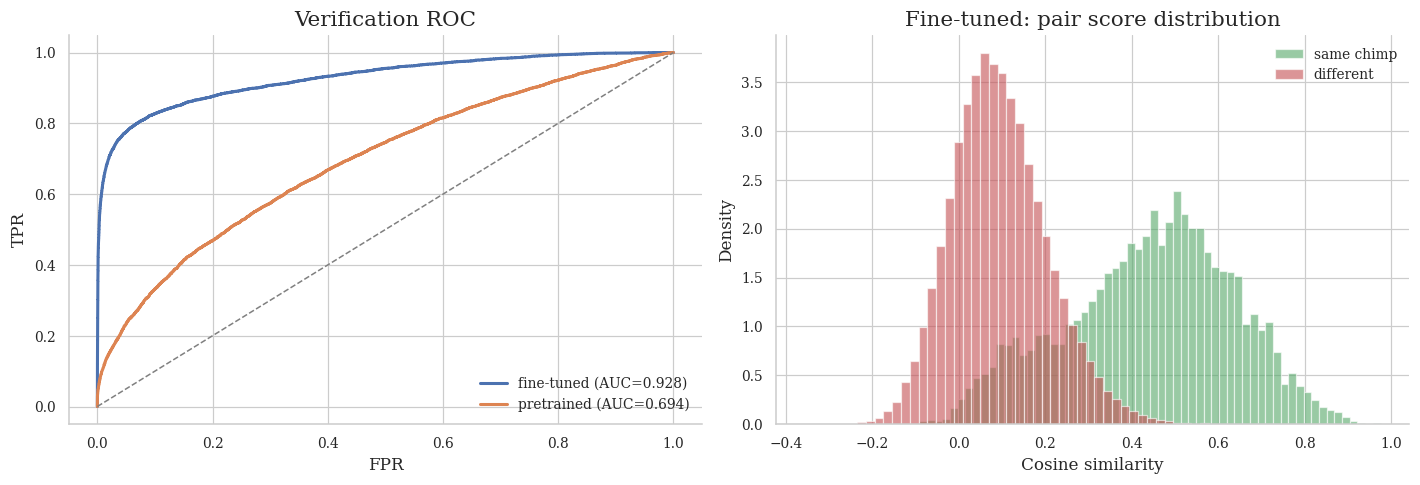

In [17]:
# =============================================================================
# 4) VERIFICATION — pairwise score distribution + ROC + EER
# =============================================================================
def build_pair_scores(emb, labels, max_pairs=200_000, seed=42):
    rng = np.random.default_rng(seed)
    lab = np.array(labels); n = len(lab)
    target = min(max_pairs, n*(n-1)//2)
    seen = set(); s = []; y = []
    while len(s) < target:
        i, j = int(rng.integers(0, n)), int(rng.integers(0, n))
        if i == j: continue
        a, b = (i, j) if i < j else (j, i)
        if (a, b) in seen: continue
        seen.add((a, b))
        s.append(float(np.dot(emb[a], emb[b])))
        y.append(int(lab[a] == lab[b]))
    return np.array(s, dtype=np.float32), np.array(y, dtype=np.int32)


def verification_metrics(emb, labels, max_pairs=200_000):
    s, y = build_pair_scores(emb, labels, max_pairs=max_pairs)
    if len(np.unique(y)) < 2:
        return {"auc": float("nan"), "eer": float("nan"), "n_pairs": len(s)}, s, y
    auc = float(roc_auc_score(y, s))
    fpr, tpr, _ = roc_curve(y, s)
    eer_idx = int(np.nanargmin(np.abs((1 - tpr) - fpr)))
    eer = float(((1 - tpr)[eer_idx] + fpr[eer_idx]) / 2)
    return {"auc": auc, "eer": eer, "n_pairs": len(s)}, s, y


ft_ver, ft_s, ft_y = verification_metrics(ft_test_emb, ft_test_labels)
pt_ver, pt_s, pt_y = verification_metrics(pt_test_emb, pt_test_labels)
fn_ver, fn_s, fn_y = verification_metrics(fn_test_emb, fn_test_labels)

ver_df = pd.DataFrame([
    {"model": "fine_tuned_intensive", **ft_ver},
    {"model": "chimpufe_pretrained_340k", **pt_ver},
    {"model": "FaceNet-FC", **fn_ver},
    {"model": "delta", "auc": ft_ver["auc"]-pt_ver["auc"],
                       "eer": ft_ver["eer"]-pt_ver["eer"], "n_pairs": ft_ver["n_pairs"]},
])
display(ver_df.style.format({"auc":"{:.4f}","eer":"{:.4f}"}))
ver_df.to_csv(EVAL_OUT_DIR / "test_verification_metrics.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# ROC
for name, s, y, c in [("fine-tuned", ft_s, ft_y, "C0"),
                      ("pretrained", pt_s, pt_y, "C1")]:
    fpr, tpr, _ = roc_curve(y, s)
    auc = roc_auc_score(y, s)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", lw=2, color=c)
axes[0].plot([0,1],[0,1], "--", color="gray", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Verification ROC"); axes[0].legend()
# Score histograms (fine-tuned)
axes[1].hist(ft_s[ft_y == 1], bins=60, alpha=0.6, label="same chimp",  color="C2", density=True)
axes[1].hist(ft_s[ft_y == 0], bins=60, alpha=0.6, label="different",   color="C3", density=True)
axes[1].set_xlabel("Cosine similarity"); axes[1].set_ylabel("Density")
axes[1].set_title("Fine-tuned: pair score distribution")
axes[1].legend()
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_roc_and_pair_dist.png", dpi=200)
plt.show()


,model,intra_mean,intra_std,inter_mean,inter_std,separation,silhouette_cos
0,FaceNet-FC,0.4291,0.3476,0.3574,0.3471,0.0717,-0.2195
1,chimpufe_pretrained_340k,0.3572,0.1623,0.2495,0.1266,0.1076,0.0246
2,fine_tuned,0.4402,0.1939,0.0939,0.1112,0.3463,0.2527


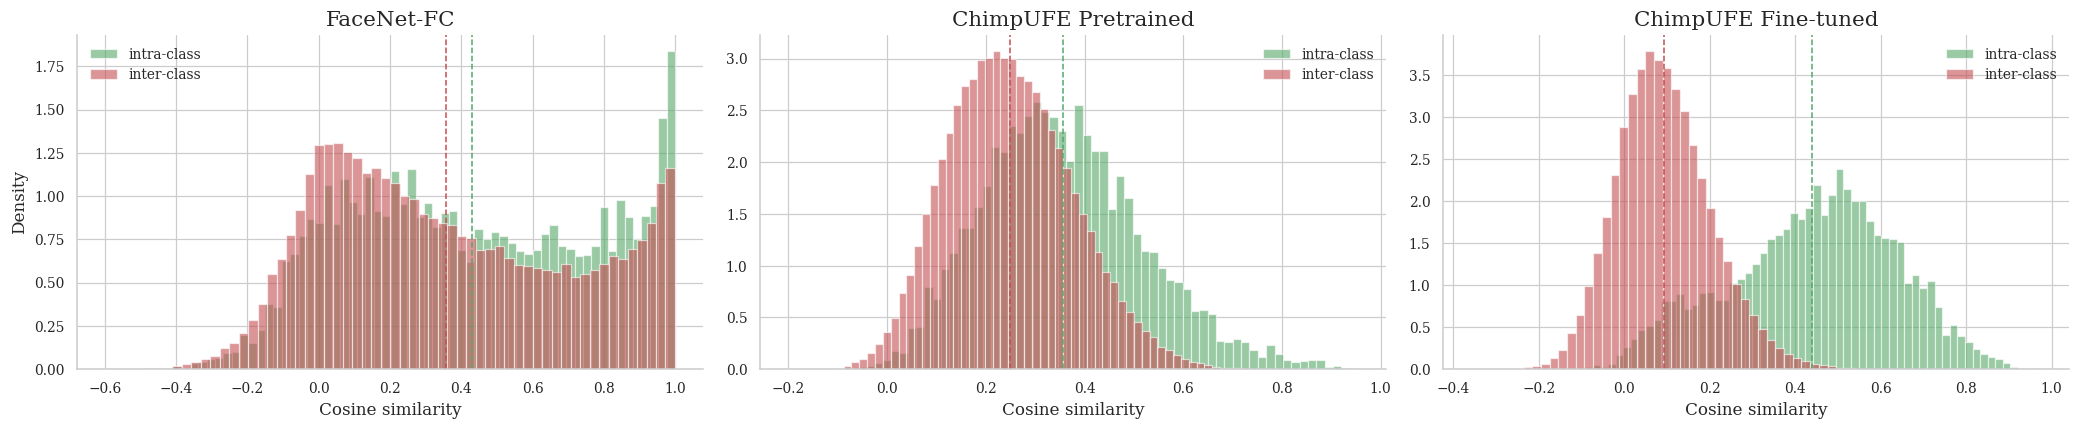

In [18]:
# =============================================================================
# 5) EMBEDDING GEOMETRY — intra/inter-class cosine + silhouette
# =============================================================================
def intra_inter_stats(emb, labels):
    lab = np.array(labels); n = len(lab)
    sim = emb @ emb.T
    iu = np.triu_indices(n, k=1)
    same = (lab[iu[0]] == lab[iu[1]])
    intra = sim[iu][same]
    inter = sim[iu][~same]
    return {
        "intra_mean": float(intra.mean()), "intra_std": float(intra.std()),
        "inter_mean": float(inter.mean()), "inter_std": float(inter.std()),
        "separation": float(intra.mean() - inter.mean()),
    }, intra, inter


ft_geom, ft_intra, ft_inter = intra_inter_stats(ft_test_emb, ft_test_labels)
pt_geom, pt_intra, pt_inter = intra_inter_stats(pt_test_emb, pt_test_labels)
fn_geom, fn_intra, fn_inter = intra_inter_stats(fn_test_emb, fn_test_labels)

# Silhouette (cosine distance) on test embeddings
ft_sil = silhouette_score(ft_test_emb, ft_test_labels, metric="cosine") if len(set(ft_test_labels)) > 1 else float("nan")
pt_sil = silhouette_score(pt_test_emb, pt_test_labels, metric="cosine") if len(set(pt_test_labels)) > 1 else float("nan")
fn_sil = silhouette_score(fn_test_emb, fn_test_labels, metric="cosine") if len(set(fn_test_labels)) > 1 else float("nan")
ft_geom["silhouette_cos"] = float(ft_sil)
pt_geom["silhouette_cos"] = float(pt_sil)
fn_geom["silhouette_cos"] = float(fn_sil)
geom_df = pd.DataFrame([
    {"model": "FaceNet-FC", **fn_geom},
    {"model": "chimpufe_pretrained_340k", **pt_geom},
    {"model": "fine_tuned", **ft_geom},
])
display(geom_df.style.format({c: "{:.4f}" for c in geom_df.columns if c != "model"}))
geom_df.to_csv(EVAL_OUT_DIR / "test_embedding_geometry.csv", index=False)

# Plot intra vs inter histograms for both models side by side
fig, axes = plt.subplots(1, 3, figsize=(19, 4))
for ax, name, intra, inter in [(axes[0], "FaceNet-FC", fn_intra, fn_inter),
                               (axes[1], "ChimpUFE Pretrained", pt_intra, pt_inter),
                               (axes[2], "ChimpUFE Fine-tuned", ft_intra, ft_inter)]:
    
    ax.hist(intra, bins=60, alpha=0.6, label="intra-class", color="C2", density=True)
    ax.hist(inter, bins=60, alpha=0.6, label="inter-class", color="C3", density=True)
    ax.axvline(intra.mean(), color="C2", ls="--", lw=1)
    ax.axvline(inter.mean(), color="C3", ls="--", lw=1)
    ax.set_xlabel("Cosine similarity"); ax.set_title(name)
    ax.legend()
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_intra_inter_distribution.png", dpi=500)
plt.show()


In [19]:
# === Notebook fix: define ft_correct and compute risk-coverage data used by the plot
import numpy as np

# Boolean mask: whether prototype prediction matches true label
ft_correct = np.array(ft_pred_proto) == np.array(ft_test_labels)

# Ensure margins array is a numpy array
ft_margins = np.asarray(ft_margins)

# Build risk-coverage curve: for k=1..n, coverage=k/n, accuracy=accuracy on top-k by margin
n = len(ft_margins)
order = np.argsort(-ft_margins)  # indices sorted by descending margin (most confident first)
coverages = np.arange(1, n + 1) / float(n)
accuracies = [float(ft_correct[order][:k].mean()) for k in range(1, n + 1)]
riskcov_df = pd.DataFrame({"coverage": coverages, "accuracy": accuracies})

# Coverage points of interest (closest achievable coverage and their accuracies)
targets = [1.0, 0.8, 0.6]
coverage_points = []
for t in targets:
    k = max(1, int(round(t * n)))
    coverage_points.append({"coverage": float(k / n), "accuracy": float(ft_correct[order][:k].mean())})
coverage_points_df = pd.DataFrame(coverage_points)

# Small sanity prints
print(f"Computed ft_correct: {ft_correct.sum()} correct / {len(ft_correct)} total")
print(riskcov_df)


Computed ft_correct: 427 correct / 500 total
     coverage  accuracy
0       0.002  1.000000
1       0.004  1.000000
2       0.006  1.000000
3       0.008  1.000000
4       0.010  1.000000
..        ...       ...
495     0.992  0.858871
496     0.994  0.857143
497     0.996  0.857430
498     0.998  0.855711
499     1.000  0.854000

[500 rows x 2 columns]


tau=0.2 | accepted=334, rejected=166, accepted_correct=321, accepted_wrong=13, rejected_correct=106, rejected_wrong=60
tau=0.2 | accepted=334, rejected=166, accepted_correct=321, accepted_wrong=13, rejected_correct=106, rejected_wrong=60
tau=0.4 | accepted=137, rejected=363, accepted_correct=134, accepted_wrong=3, rejected_correct=293, rejected_wrong=70
tau=0.4 | accepted=137, rejected=363, accepted_correct=134, accepted_wrong=3, rejected_correct=293, rejected_wrong=70


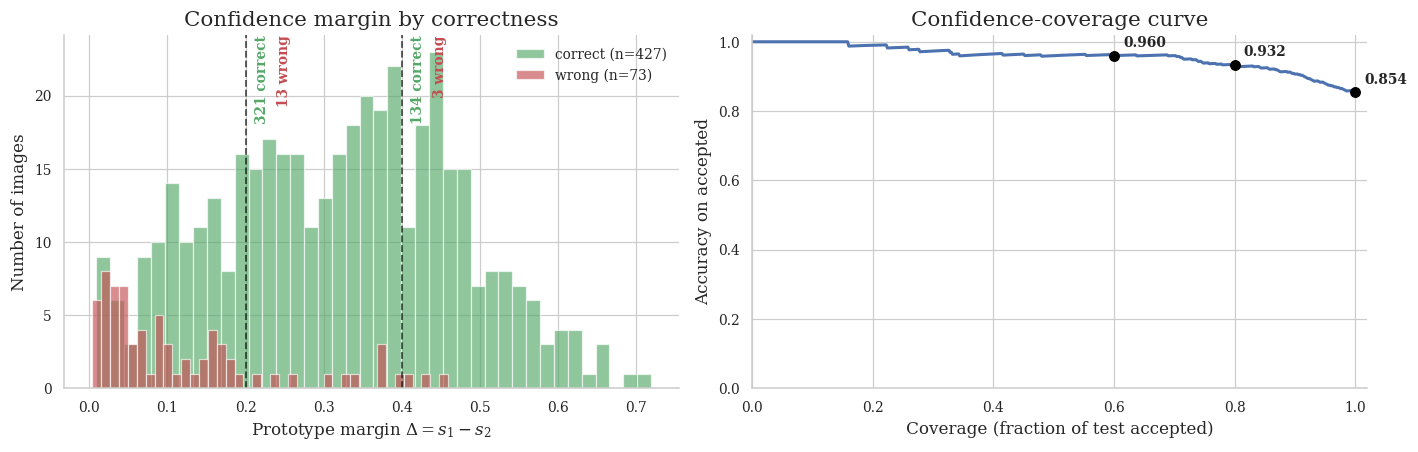

In [20]:
# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# ------------------------------------------------------------
# Left: margin distribution for correct vs wrong predictions
# ------------------------------------------------------------
axes[0].hist(
    ft_margins[ft_correct],
    bins=40,
    alpha=0.65,
    color="C2",
    label=f"correct (n={ft_correct.sum()})",
    density=False,
)

axes[0].hist(
    ft_margins[~ft_correct],
    bins=40,
    alpha=0.65,
    color="C3",
    label=f"wrong (n={(~ft_correct).sum()})",
    density=False,
)


fixed_thresholds = [0.2, 0.4]

# Get y-axis limit after drawing the histograms
ymax = axes[0].get_ylim()[1]

for i, tau in enumerate(fixed_thresholds):
    accept = ft_margins >= tau
    reject = ~accept

    # Accepted predictions only
    accepted_total = int(accept.sum())
    accepted_correct = int((ft_correct & accept).sum())
    accepted_wrong = int((~ft_correct & accept).sum())

    # Rejected counts are only printed, not shown on the graph
    rejected_total = int(reject.sum())
    rejected_correct = int((ft_correct & reject).sum())
    rejected_wrong = int((~ft_correct & reject).sum())

    # Draw dashed threshold line
    axes[0].axvline(
        tau,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.65,
    )

    # Vertical offsets to avoid overlap between tau=0.2 and tau=0.4 labels
    y_green = ymax * (1.0)
    y_red = ymax * (1.0)

    # Green vertical label: accepted correct predictions
    axes[0].text(
        tau + 0.012,
        y_green,
        f"{accepted_correct} correct",
        color="C2",
        fontsize=9,
        weight="bold",
        rotation=90,
        ha="left",
        va="top",
    )

    # Red vertical label: accepted wrong predictions
    axes[0].text(
        tau + 0.040,
        y_red,
        f"{accepted_wrong} wrong",
        color="C3",
        fontsize=9,
        weight="bold",
        rotation=90,
        ha="left",
        va="top",
    )

    # Print complete interpretation to console
    print(
        f"tau={tau:.1f} | "
        f"accepted={accepted_total}, rejected={rejected_total}, "
        f"accepted_correct={accepted_correct}, accepted_wrong={accepted_wrong}, "
        f"rejected_correct={rejected_correct}, rejected_wrong={rejected_wrong}"
    )


    # Print complete interpretation to console
    print(
        f"tau={tau:.1f} | "
        f"accepted={accepted_total}, rejected={rejected_total}, "
        f"accepted_correct={accepted_correct}, accepted_wrong={accepted_wrong}, "
        f"rejected_correct={rejected_correct}, rejected_wrong={rejected_wrong}"
    )

axes[0].set_xlabel(r"Prototype margin $\Delta = s_1 - s_2$")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Confidence margin by correctness")
axes[0].legend()

# ------------------------------------------------------------
# Right: confidence-coverage curve
# ------------------------------------------------------------
axes[1].plot(
    riskcov_df["coverage"],
    riskcov_df["accuracy"],
    lw=2,
    color="C0",
)

# Add points for target coverage 1.0, 0.8, 0.6
# Only accuracy values are written on the graph.
for _, row in coverage_points_df.iterrows():
    coverage = row["coverage"]
    accuracy = row["accuracy"]

    axes[1].scatter(
        coverage,
        accuracy,
        color="black",
        s=40,
        zorder=5,
    )

    axes[1].annotate(
        f"{accuracy:.3f}",
        xy=(coverage, accuracy),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
    )

axes[1].set_xlabel("Coverage (fraction of test accepted)")
axes[1].set_ylabel("Accuracy on accepted")
axes[1].set_title("Confidence-coverage curve")
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()

plt.savefig(
    EVAL_OUT_DIR / "test_confidence_and_riskcov.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    EVAL_OUT_DIR / "test_confidence_and_riskcov.pdf",
    bbox_inches="tight",
)

plt.show()

In [21]:
# =============================================================================
# 7) PER-IMAGE COMPARISON TABLE — fine-tuned head + prototype + pretrained proto
# =============================================================================
softmax_logits = ft_test_logits  # for fine-tuned head
softmax_probs  = (softmax_logits - softmax_logits.max(axis=1, keepdims=True))
softmax_probs  = np.exp(softmax_probs)
softmax_probs /= softmax_probs.sum(axis=1, keepdims=True)
pred_head_top1 = [idx_to_class[i] for i in pred_top1]
pred_head_conf = softmax_probs.max(axis=1)

per_image = pd.DataFrame({
    "image": [Path(p).name for p in ft_test_paths],
    "true_chimp": ft_test_labels,
    "pred_head_ft": pred_head_top1,
    "head_confidence": pred_head_conf,
    "pred_proto_ft": ft_pred_proto,
    "proto_margin_ft": ft_margins,
    "pred_proto_pre": pt_pred_proto,
    "proto_margin_pre": pt_margins,
})
per_image["head_correct"]      = (per_image.pred_head_ft   == per_image.true_chimp)
per_image["proto_ft_correct"]  = (per_image.pred_proto_ft  == per_image.true_chimp)
per_image["proto_pre_correct"] = (per_image.pred_proto_pre == per_image.true_chimp)
per_image = per_image.sort_values(["true_chimp", "image"]).reset_index(drop=True)

print("Image-level test accuracy:")
print(f"  fine-tuned head        : {per_image.head_correct.mean():.4f}")
print(f"  fine-tuned prototypes  : {per_image.proto_ft_correct.mean():.4f}")
print(f"  pretrained prototypes  : {per_image.proto_pre_correct.mean():.4f}")

per_image.to_csv(EVAL_OUT_DIR / "test_per_image_predictions.csv", index=False)

# Failure cases for fine-tuned head
failures = per_image[~per_image.head_correct].copy()
failures = failures.sort_values("head_confidence", ascending=False)
print(f"\nFine-tuned head failures: {len(failures)} / {len(per_image)}")
display(failures.head(20))
failures.to_csv(EVAL_OUT_DIR / "test_failures_fine_tuned_head.csv", index=False)


Image-level test accuracy:
  fine-tuned head        : 0.8680
  fine-tuned prototypes  : 0.8540
  pretrained prototypes  : 0.2780

Fine-tuned head failures: 66 / 500


,image,true_chimp,pred_head_ft,head_confidence,pred_proto_ft,proto_margin_ft,pred_proto_pre,proto_margin_pre,head_correct,proto_ft_correct,proto_pre_correct
182,KG_16.png,kassongo,muke,0.999969,muke,0.377848,maniema,0.112041,False,False,False
242,LM_25.png,lwama,tanganica,0.999918,tanganica,0.411754,nganja,0.043118,False,False,False
382,NR_16.png,nzuri,maniema,0.999890,maniema,0.459292,maniema,0.187977,False,False,False
243,LM_26.png,lwama,tanganica,0.999732,tanganica,0.378609,kira,0.024000,False,False,False
227,LM_11.png,lwama,djiku,0.999279,djiku,0.323320,kira,0.000787,False,False,False
282,MM_17.png,maniema,binasera,0.998869,binasera,0.398589,malago,0.022593,False,False,False
439,TS_22.png,talisa,maniema,0.997890,maniema,0.262182,maniema,0.080545,False,False,False
380,NR_14.png,nzuri,maniema,0.997427,maniema,0.309771,maniema,0.015121,False,False,False
22,AD_7.png,amadi,maniema,0.997301,maniema,0.342039,maniema,0.059308,False,False,False
193,KG_3.png,kassongo,kira,0.993284,kira,0.220136,kira,0.012821,False,False,False


Per-chimp accuracy comparison (sorted by fine-tuned vs pretrained gain):


,chimp,n_test,ft_head_acc,ft_proto_acc,pt_proto_acc,ft_proto_margin,pt_proto_margin,ft_head_conf,ft_vs_pt_gain
19,tingitingi,25,1.000,1.000,0.000,0.252,0.034,0.975,1.000
1,banalia,25,0.920,0.920,0.040,0.319,0.026,0.977,0.880
8,kira,25,1.000,1.000,0.160,0.357,0.032,0.986,0.840
5,jeje,25,0.840,0.840,0.040,0.264,0.044,0.941,0.800
0,amadi,25,0.840,0.840,0.200,0.278,0.023,0.932,0.640
15,nzuri,25,0.800,0.800,0.240,0.303,0.048,0.946,0.560
14,nganja,25,0.880,0.880,0.320,0.313,0.040,0.941,0.560
4,ivan,25,1.000,1.000,0.520,0.244,0.037,0.979,0.480
16,penda,25,0.800,0.880,0.520,0.270,0.043,0.934,0.360
9,lwama,25,0.760,0.760,0.440,0.279,0.036,0.921,0.320


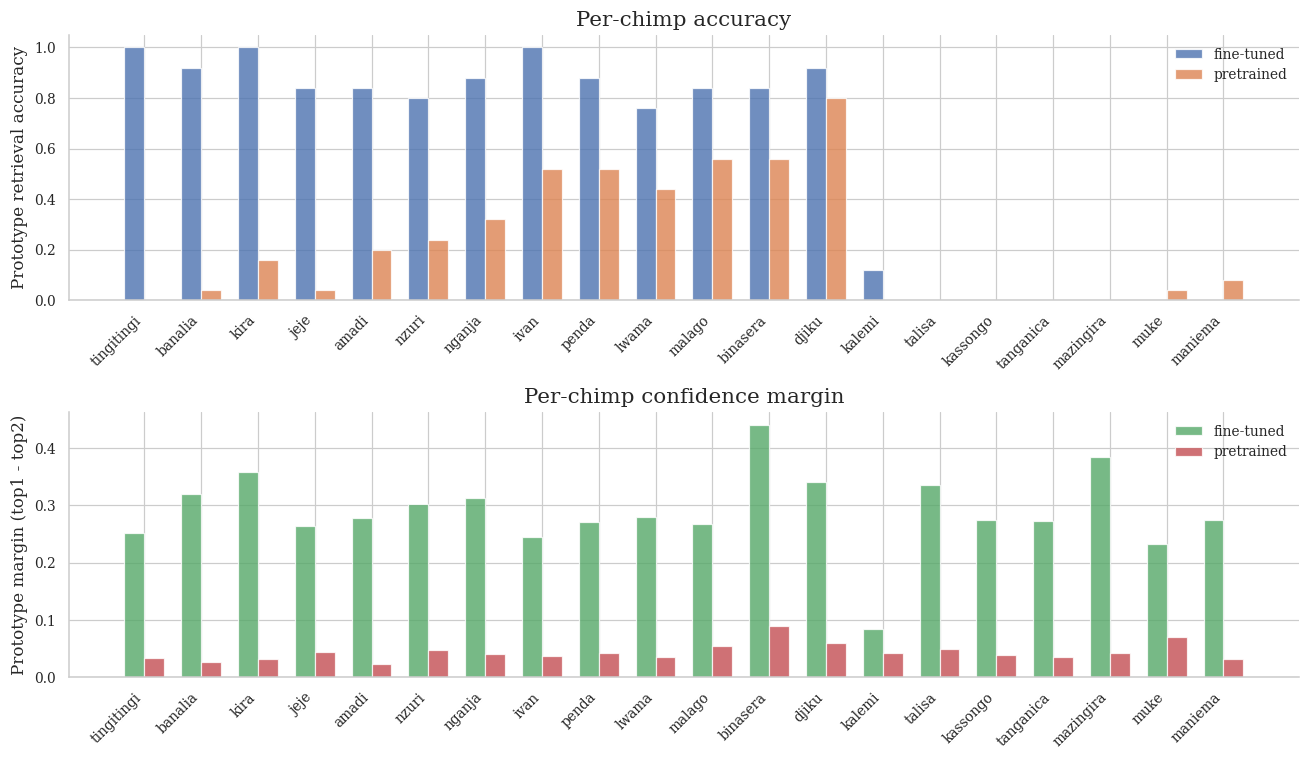

In [22]:

# Per-chimp accuracy comparison
per_class_comparison = []
for chimp in CANONICAL_NAMES:
    test_mask = np.array(ft_test_labels) == chimp
    if not test_mask.any():
        continue
    
    # Fine-tuned head accuracy
    ft_head_acc = (per_image.loc[test_mask.tolist(), "pred_head_ft"].values == chimp).mean()
    # Fine-tuned prototype accuracy
    ft_proto_acc = (per_image.loc[test_mask.tolist(), "pred_proto_ft"].values == chimp).mean()
    # Pretrained prototype accuracy
    pt_proto_acc = (per_image.loc[test_mask.tolist(), "pred_proto_pre"].values == chimp).mean()
    
    # Mean margin for fine-tuned prototype
    ft_proto_margin = per_image.loc[test_mask.tolist(), "proto_margin_ft"].mean()
    pt_proto_margin = per_image.loc[test_mask.tolist(), "proto_margin_pre"].mean()
    
    # Mean confidence for fine-tuned head
    ft_head_conf = per_image.loc[test_mask.tolist(), "head_confidence"].mean()
    
    per_class_comparison.append({
        "chimp": chimp,
        "n_test": test_mask.sum(),
        "ft_head_acc": ft_head_acc,
        "ft_proto_acc": ft_proto_acc,
        "pt_proto_acc": pt_proto_acc,
        "ft_proto_margin": ft_proto_margin,
        "pt_proto_margin": pt_proto_margin,
        "ft_head_conf": ft_head_conf,
        "ft_vs_pt_gain": ft_proto_acc - pt_proto_acc,
    })

per_class_df = pd.DataFrame(per_class_comparison).sort_values("ft_vs_pt_gain", ascending=False)
print("Per-chimp accuracy comparison (sorted by fine-tuned vs pretrained gain):")
display(per_class_df.style.format({
    "ft_head_acc": "{:.3f}", "ft_proto_acc": "{:.3f}", "pt_proto_acc": "{:.3f}",
    "ft_proto_margin": "{:.3f}", "pt_proto_margin": "{:.3f}", "ft_head_conf": "{:.3f}",
    "ft_vs_pt_gain": "{:.3f}"
}))
per_class_df.to_csv(EVAL_OUT_DIR / "test_per_class_comparison.csv", index=False)

# Visualize per-chimp improvement
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
# Accuracy comparison
x = np.arange(len(per_class_df))
w = 0.35
axes[0].bar(x - w/2, per_class_df["ft_proto_acc"], w, label="fine-tuned", color="C0", alpha=0.8)
axes[0].bar(x + w/2, per_class_df["pt_proto_acc"], w, label="pretrained", color="C1", alpha=0.8)
axes[0].set_ylabel("Prototype retrieval accuracy"); axes[0].set_title("Per-chimp accuracy")
axes[0].set_xticks(x); axes[0].set_xticklabels(per_class_df["chimp"], rotation=45, ha="right")
axes[0].legend(); axes[0].set_ylim(0, 1.05)
# Margin comparison
axes[1].bar(x - w/2, per_class_df["ft_proto_margin"], w, label="fine-tuned", color="C2", alpha=0.8)
axes[1].bar(x + w/2, per_class_df["pt_proto_margin"], w, label="pretrained", color="C3", alpha=0.8)
axes[1].set_ylabel("Prototype margin (top1 - top2)"); axes[1].set_title("Per-chimp confidence margin")
axes[1].set_xticks(x); axes[1].set_xticklabels(per_class_df["chimp"], rotation=45, ha="right")
axes[1].legend()
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_per_class_comparison_bars.png", dpi=200)
plt.show()



## 7b) Detailed Per-Class Comparison: Fine-Tuned vs Pretrained

Compare accuracy, margin, and confidence metrics for each chimp identity between models.


## 8) Embedding visualizations and qualitative inspection

- t-SNE / PCA of test embeddings (fine-tuned vs pretrained)
- Side-by-side visual review of test images with model predictions


Fine-tuned errors: 73 (14.6%)
Pretrained errors: 361 (72.2%)

Top confusion cases - FINE-TUNED:


,true_chimp,pred_proto_ft,count
26,maniema,binasera,5
39,nzuri,maniema,4
6,binasera,maniema,3
15,kassongo,muke,3
23,malago,ivan,3
12,kassongo,kalemi,3
44,tanganica,amadi,3
16,kassongo,nzuri,3
27,maniema,kira,2
25,maniema,amadi,2



Top confusion cases - PRETRAINED:


,true_chimp,pred_proto_pre,count
36,jeje,malago,11
88,maniema,tanganica,7
75,malago,ivan,6
116,nzuri,malago,6
117,nzuri,maniema,6
112,nganja,malago,6
12,banalia,lwama,6
49,kassongo,banalia,6
91,mazingira,kira,5
43,kalemi,lwama,5



Hardest errors (lowest margin) - FINE-TUNED:


,image,true_chimp,pred_proto_ft,proto_margin_ft
189,KG_22.png,kassongo,kalemi,0.003827
178,KG_12.png,kassongo,kalemi,0.004176
461,TC_28.png,tanganica,amadi,0.008456
149,JJ_8.png,jeje,lwama,0.009942
41,BL_24.png,banalia,kalemi,0.010460
186,KG_2.png,kassongo,kira,0.011906
184,KG_18.png,kassongo,penda,0.016668
198,KG_8.png,kassongo,muke,0.017392
302,MZ_11.png,mazingira,kira,0.018850
423,PD_8.png,penda,maniema,0.020833



Hardest errors (lowest margin) - PRETRAINED:


,image,true_chimp,pred_proto_pre,proto_margin_pre
46,BL_6.png,banalia,malago,0.000100
426,TS_10.png,talisa,binasera,0.000246
87,DK_21.png,djiku,kira,0.000248
9,AD_19.png,amadi,lwama,0.000370
295,MM_5.png,maniema,amadi,0.000433
6,AD_16.png,amadi,lwama,0.000668
227,LM_11.png,lwama,kira,0.000787
45,BL_5.png,banalia,ivan,0.000940
442,TS_25.png,talisa,malago,0.001001
109,IV_18.png,ivan,malago,0.001031



Error rate by identity (sorted by fine-tuned advantage):


,chimp,n_test,ft_error_rate,pt_error_rate,ft_advantage
19,tingitingi,25,0.000,1.000,+1.000
6,kalemi,25,0.000,0.960,+0.960
17,talisa,25,0.040,1.000,+0.960
1,banalia,25,0.080,0.960,+0.880
8,kira,25,0.000,0.840,+0.840
5,jeje,25,0.160,0.960,+0.800
13,muke,25,0.000,0.720,+0.720
0,amadi,25,0.160,0.800,+0.640
12,mazingira,25,0.200,0.800,+0.600
15,nzuri,25,0.200,0.760,+0.560


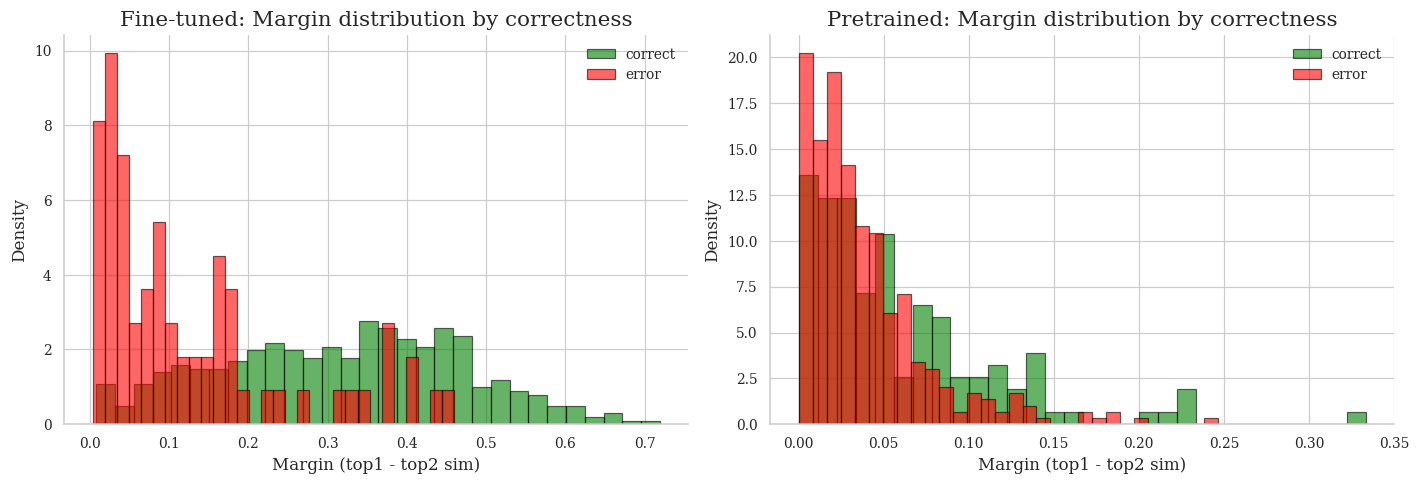

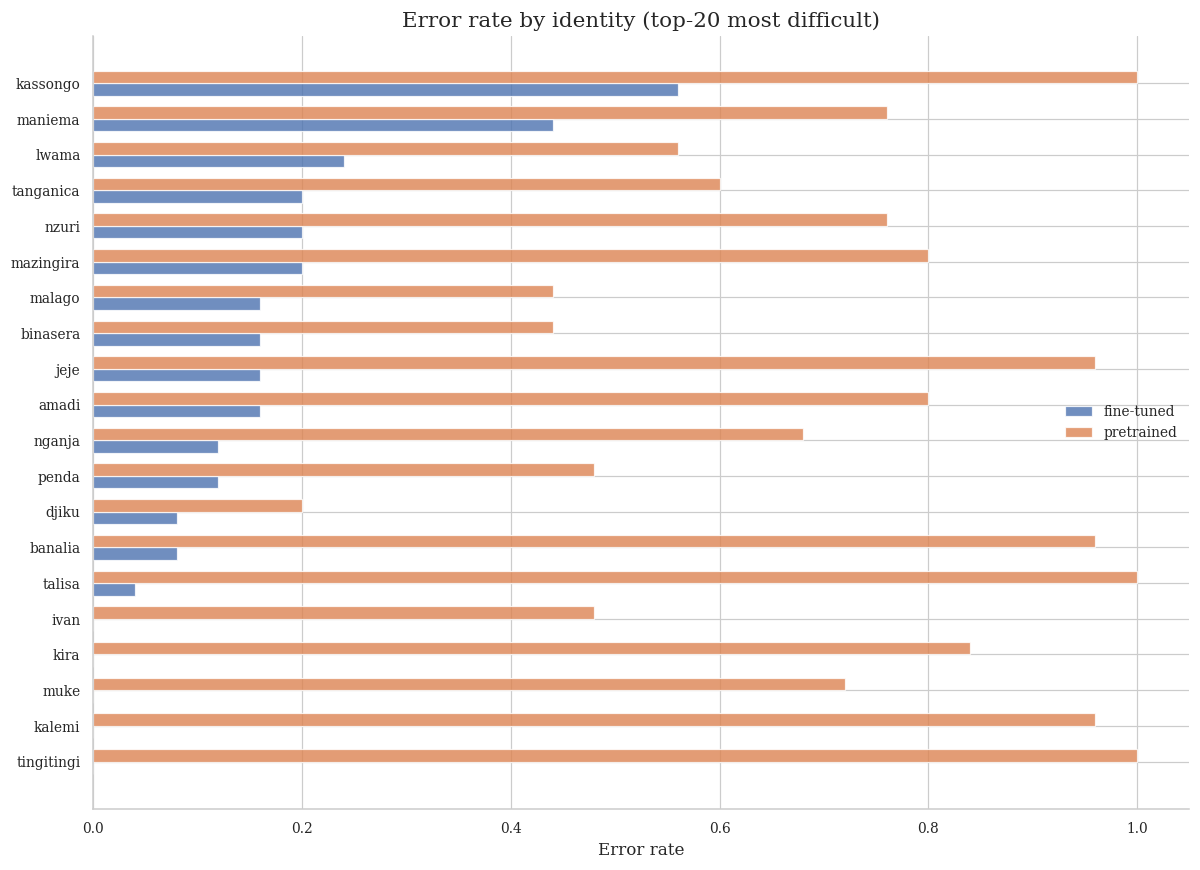

In [23]:

# Failure mode analysis
ft_errors = per_image[~per_image["proto_ft_correct"]].copy()
pt_errors = per_image[~per_image["proto_pre_correct"]].copy()

print(f"Fine-tuned errors: {len(ft_errors)} ({100*len(ft_errors)/len(per_image):.1f}%)")
print(f"Pretrained errors: {len(pt_errors)} ({100*len(pt_errors)/len(per_image):.1f}%)")

# Confusion analysis: which chimps are most confused with each other?
def confusion_analysis(pred_col, true_col, name):
    errors = per_image[per_image[pred_col] != per_image[true_col]].copy()
    confusions = errors.groupby([true_col, pred_col]).size().reset_index(name="count")
    confusions = confusions.sort_values("count", ascending=False)
    return confusions

ft_confusions = confusion_analysis("pred_proto_ft", "true_chimp", "fine-tuned")
pt_confusions = confusion_analysis("pred_proto_pre", "true_chimp", "pretrained")

print(f"\nTop confusion cases - FINE-TUNED:")
display(ft_confusions.head(10))

print(f"\nTop confusion cases - PRETRAINED:")
display(pt_confusions.head(10))

ft_confusions.to_csv(EVAL_OUT_DIR / "test_confusion_analysis_ft.csv", index=False)
pt_confusions.to_csv(EVAL_OUT_DIR / "test_confusion_analysis_pt.csv", index=False)

# Error hardness: group errors by margin (low margin = harder case)
ft_errors_sorted = ft_errors.sort_values("proto_margin_ft")
pt_errors_sorted = pt_errors.sort_values("proto_margin_pre")

print(f"\nHardest errors (lowest margin) - FINE-TUNED:")
display(ft_errors_sorted[["image", "true_chimp", "pred_proto_ft", "proto_margin_ft"]].head(10))

print(f"\nHardest errors (lowest margin) - PRETRAINED:")
display(pt_errors_sorted[["image", "true_chimp", "pred_proto_pre", "proto_margin_pre"]].head(10))

# Error rate per identity
error_rate_analysis = []
for chimp in CANONICAL_NAMES:
    mask = per_image["true_chimp"] == chimp
    if not mask.any():
        continue
    ft_err_rate = (per_image.loc[mask, "pred_proto_ft"] != chimp).mean()
    pt_err_rate = (per_image.loc[mask, "pred_proto_pre"] != chimp).mean()
    n_test = mask.sum()
    error_rate_analysis.append({
        "chimp": chimp,
        "n_test": n_test,
        "ft_error_rate": ft_err_rate,
        "pt_error_rate": pt_err_rate,
        "ft_advantage": pt_err_rate - ft_err_rate,  # positive = FT is better
    })

error_rate_df = pd.DataFrame(error_rate_analysis).sort_values("ft_advantage", ascending=False)
print("\nError rate by identity (sorted by fine-tuned advantage):")
display(error_rate_df.head(15).style.format({
    "ft_error_rate": "{:.3f}", "pt_error_rate": "{:.3f}", "ft_advantage": "{:+.3f}"
}))
error_rate_df.to_csv(EVAL_OUT_DIR / "test_error_rate_by_identity.csv", index=False)

# Visualize: hardness of errors (margin distribution for correct vs error)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Fine-tuned
axes[0].hist(per_image.loc[per_image["proto_ft_correct"], "proto_margin_ft"], 
             bins=30, alpha=0.6, label="correct", color="green", density=True, edgecolor="black")
axes[0].hist(per_image.loc[~per_image["proto_ft_correct"], "proto_margin_ft"],
             bins=30, alpha=0.6, label="error", color="red", density=True, edgecolor="black")
axes[0].set_xlabel("Margin (top1 - top2 sim)"); axes[0].set_ylabel("Density")
axes[0].set_title("Fine-tuned: Margin distribution by correctness")
axes[0].legend()

# Pretrained
axes[1].hist(per_image.loc[per_image["proto_pre_correct"], "proto_margin_pre"],
             bins=30, alpha=0.6, label="correct", color="green", density=True, edgecolor="black")
axes[1].hist(per_image.loc[~per_image["proto_pre_correct"], "proto_margin_pre"],
             bins=30, alpha=0.6, label="error", color="red", density=True, edgecolor="black")
axes[1].set_xlabel("Margin (top1 - top2 sim)"); axes[1].set_ylabel("Density")
axes[1].set_title("Pretrained: Margin distribution by correctness")
axes[1].legend()

plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_error_hardness_by_margin.png", dpi=200)
plt.show()

# Per-chimp error rate comparison
fig, ax = plt.subplots(figsize=(11, 8))
error_plot = error_rate_df.sort_values("ft_error_rate").tail(20)
x = np.arange(len(error_plot))
w = 0.35
ax.barh(x - w/2, error_plot["ft_error_rate"], w, label="fine-tuned", color="C0", alpha=0.8)
ax.barh(x + w/2, error_plot["pt_error_rate"], w, label="pretrained", color="C1", alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(error_plot["chimp"])
ax.set_xlabel("Error rate"); ax.set_title("Error rate by identity (top-20 most difficult)")
ax.legend()
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_error_rate_comparison.png", dpi=200)
plt.show()



## 7g) Failure Mode Analysis

Compare types and patterns of errors: confusion matrix divergence, hard cases, systematic biases.


Embedding Quality Metrics:


,model,norm_mean,norm_std,norm_min,norm_max,pairwise_sim_mean,pairwise_sim_std,n_samples
0,fine_tuned,1.0000,0.0000,1.0000,1.0000,0.1105,0.1381,500
1,pretrained,1.0000,0.0000,1.0000,1.0000,0.2547,0.1306,500


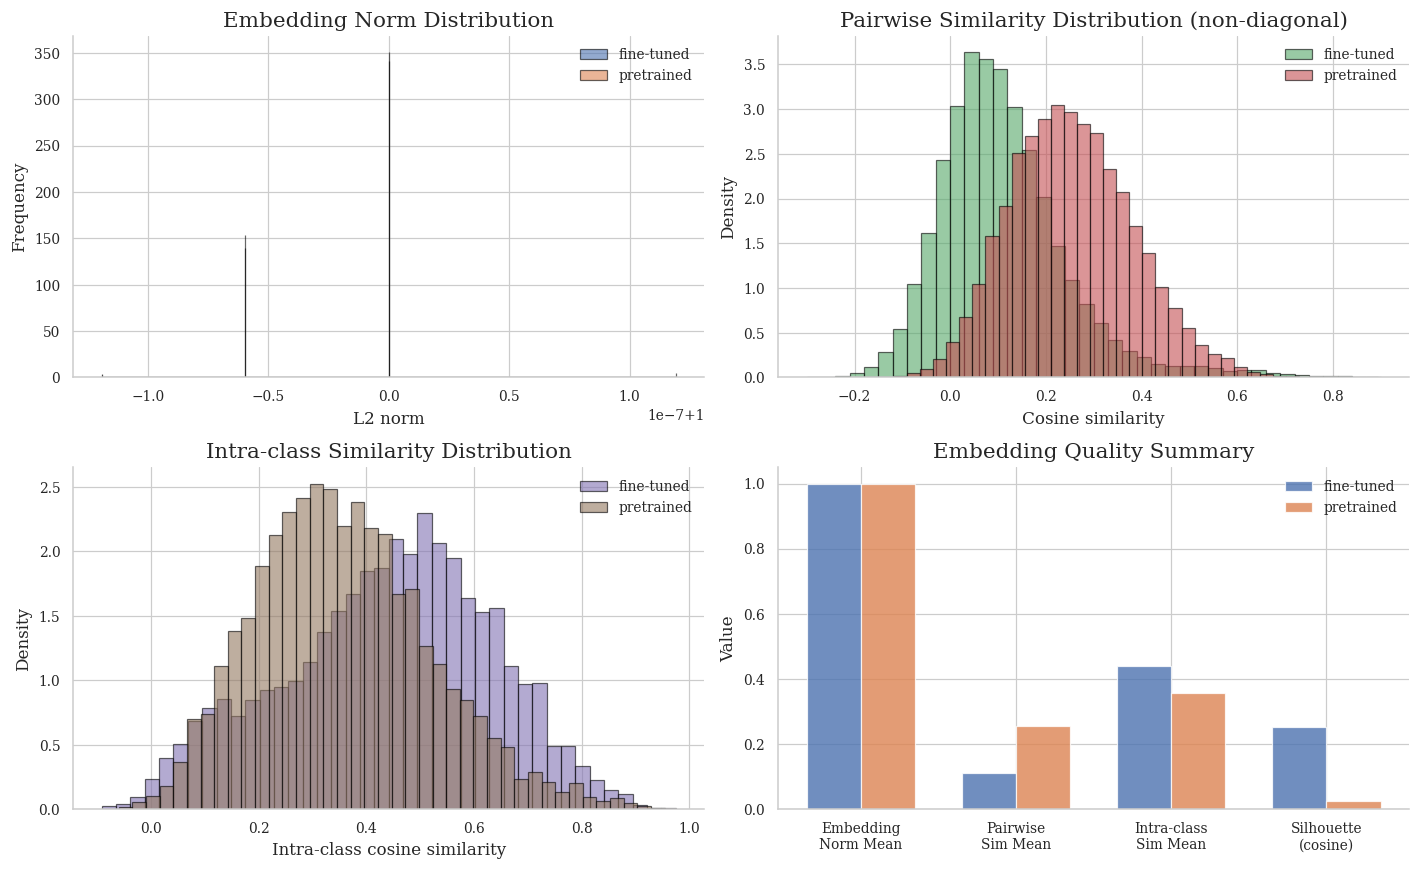

In [24]:

# Embedding quality metrics
def embedding_stats(emb):
    """Compute statistics on embedding space"""
    # Embedding norms (should all be ~1 for L2-normalized)
    norms = np.linalg.norm(emb, axis=1)
    # Embedding diversity (mean pairwise distance)
    # Sample to avoid O(n^2) computation
    if len(emb) > 500:
        indices = np.random.choice(len(emb), 500, replace=False)
        sample_emb = emb[indices]
    else:
        sample_emb = emb
    sim_matrix = sample_emb @ sample_emb.T
    # Exclude diagonal
    np.fill_diagonal(sim_matrix, np.nan)
    mean_sim = float(np.nanmean(sim_matrix))
    std_sim = float(np.nanstd(sim_matrix))
    
    return {
        "norm_mean": float(norms.mean()),
        "norm_std": float(norms.std()),
        "norm_min": float(norms.min()),
        "norm_max": float(norms.max()),
        "pairwise_sim_mean": mean_sim,
        "pairwise_sim_std": std_sim,
        "n_samples": len(emb),
    }

ft_emb_stats = embedding_stats(ft_test_emb)
pt_emb_stats = embedding_stats(pt_test_emb)

emb_quality_df = pd.DataFrame([
    {"model": "fine_tuned", **ft_emb_stats},
    {"model": "pretrained", **pt_emb_stats},
])
print("Embedding Quality Metrics:")
display(emb_quality_df.style.format({
    "norm_mean": "{:.4f}", "norm_std": "{:.4f}", "norm_min": "{:.4f}", "norm_max": "{:.4f}",
    "pairwise_sim_mean": "{:.4f}", "pairwise_sim_std": "{:.4f}"
}))
emb_quality_df.to_csv(EVAL_OUT_DIR / "test_embedding_quality_metrics.csv", index=False)

# Visualize embedding norms distribution
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Embedding norms
ft_norms = np.linalg.norm(ft_test_emb, axis=1)
pt_norms = np.linalg.norm(pt_test_emb, axis=1)
axes[0, 0].hist(ft_norms, bins=30, alpha=0.6, label="fine-tuned", color="C0", edgecolor="black")
axes[0, 0].hist(pt_norms, bins=30, alpha=0.6, label="pretrained", color="C1", edgecolor="black")
axes[0, 0].set_xlabel("L2 norm"); axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Embedding Norm Distribution")
axes[0, 0].legend()

# Pairwise similarity distribution (sample)
ft_sample = ft_test_emb[::max(1, len(ft_test_emb)//200)]
pt_sample = pt_test_emb[::max(1, len(pt_test_emb)//200)]
ft_sim = (ft_sample @ ft_sample.T).flatten()
pt_sim = (pt_sample @ pt_sample.T).flatten()
ft_sim = ft_sim[ft_sim < 0.9]  # exclude self-similarities
pt_sim = pt_sim[pt_sim < 0.9]
axes[0, 1].hist(ft_sim, bins=40, alpha=0.6, label="fine-tuned", color="C2", edgecolor="black", density=True)
axes[0, 1].hist(pt_sim, bins=40, alpha=0.6, label="pretrained", color="C3", edgecolor="black", density=True)
axes[0, 1].set_xlabel("Cosine similarity"); axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Pairwise Similarity Distribution (non-diagonal)")
axes[0, 1].legend()

# Intra-class vs inter-class for each model
ft_intra_per_sample = []
for lbl in set(ft_test_labels):
    idx = np.where(np.array(ft_test_labels) == lbl)[0]
    if len(idx) > 1:
        intra_sims = ft_test_emb[idx] @ ft_test_emb[idx].T
        np.fill_diagonal(intra_sims, np.nan)
        ft_intra_per_sample.extend(intra_sims.flatten())
ft_intra_per_sample = [x for x in ft_intra_per_sample if not np.isnan(x)]

pt_intra_per_sample = []
for lbl in set(pt_test_labels):
    idx = np.where(np.array(pt_test_labels) == lbl)[0]
    if len(idx) > 1:
        intra_sims = pt_test_emb[idx] @ pt_test_emb[idx].T
        np.fill_diagonal(intra_sims, np.nan)
        pt_intra_per_sample.extend(intra_sims.flatten())
pt_intra_per_sample = [x for x in pt_intra_per_sample if not np.isnan(x)]

axes[1, 0].hist(ft_intra_per_sample, bins=40, alpha=0.6, label="fine-tuned", color="C4", edgecolor="black", density=True)
axes[1, 0].hist(pt_intra_per_sample, bins=40, alpha=0.6, label="pretrained", color="C5", edgecolor="black", density=True)
axes[1, 0].set_xlabel("Intra-class cosine similarity")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Intra-class Similarity Distribution")
axes[1, 0].legend()

# Summary comparison
metrics_names = ["Embedding\nNorm Mean", "Pairwise\nSim Mean", "Intra-class\nSim Mean", "Silhouette\n(cosine)"]
ft_vals = [ft_emb_stats["norm_mean"], ft_emb_stats["pairwise_sim_mean"], 
           np.mean(ft_intra_per_sample) if ft_intra_per_sample else 0, ft_geom["silhouette_cos"]]
pt_vals = [pt_emb_stats["norm_mean"], pt_emb_stats["pairwise_sim_mean"],
           np.mean(pt_intra_per_sample) if pt_intra_per_sample else 0, pt_geom["silhouette_cos"]]

x = np.arange(len(metrics_names))
w = 0.35
axes[1, 1].bar(x - w/2, ft_vals, w, label="fine-tuned", color="C0", alpha=0.8)
axes[1, 1].bar(x + w/2, pt_vals, w, label="pretrained", color="C1", alpha=0.8)
axes[1, 1].set_ylabel("Value"); axes[1, 1].set_title("Embedding Quality Summary")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_embedding_quality_analysis.png", dpi=200)
plt.show()



## 7f) Feature Space Analysis: Embedding Quality Metrics

Compare embedding norms, diversity, and cluster cohesion between models.



Ranking Agreement Metrics (n=500):
  Kendall tau (full ranking):
    Mean: 0.0300
    Std:  0.1684
  Top-5 overlap fraction:
    Mean: 0.5140
    Std:  0.1879

Per-chimp ranking agreement:


kendall_tau        top5_overlap       
                  mean    std         mean    std
true_chimp                                       
amadi           -0.024  0.194        0.488  0.174
banalia          0.009  0.149        0.496  0.184
binasera         0.032  0.120        0.528  0.114
djiku            0.080  0.159        0.656  0.123
ivan             0.013  0.165        0.576  0.176
jeje             0.038  0.185        0.576  0.194
kalemi           0.077  0.146        0.496  0.174
kassongo         0.003  0.155        0.504  0.209
kira             0.057  0.150        0.464  0.170
lwama            0.055  0.162        0.520  0.163
malago           0.003  0.169        0.488  0.142
maniema          0.034  0.146        0.416  0.264
mazingira        0.059  0.225        0.592  0.158
muke             0.001  0.187        0.528  0.230
nganja          -0.013  0.186        0.472  0.172

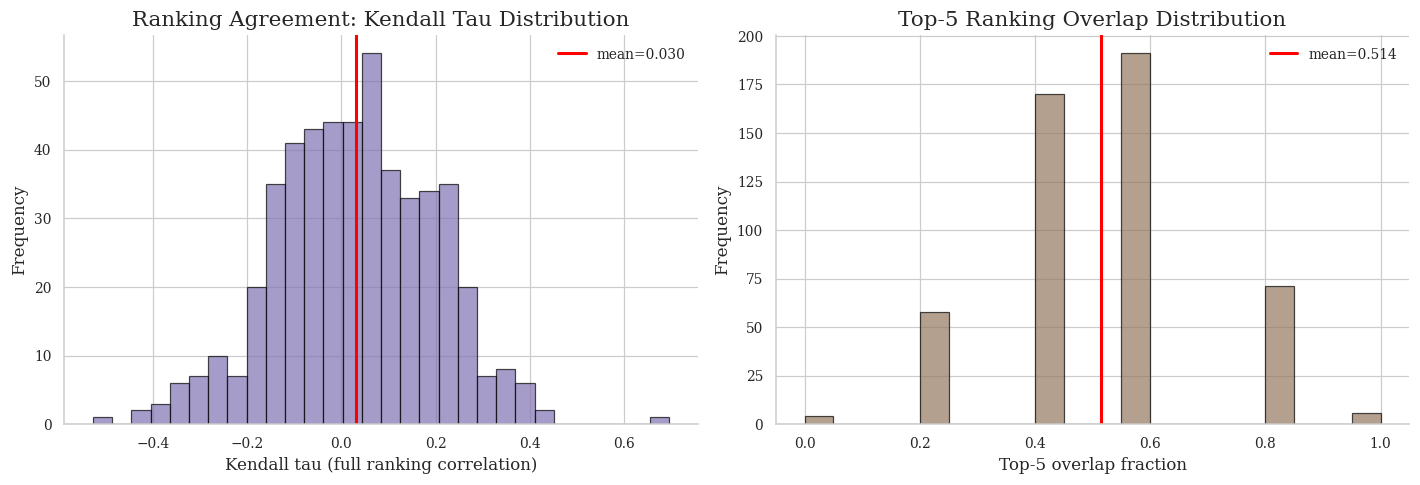

In [25]:

# Ranking agreement: how often do the two models rank candidates the same?
from scipy.stats import kendalltau, spearmanr

ranking_diffs = []
for i in range(len(ft_test_labels)):
    ft_rank = np.argsort(-ft_proto_sim[i])
    pt_rank = np.argsort(-pt_proto_sim[i])
    # Kendall tau: correlation between two rankings
    tau, _ = kendalltau(ft_rank, pt_rank)
    # NDCG comparison (only top-5)
    ft_top5_mask = ft_rank[:5]
    pt_top5_mask = pt_rank[:5]
    overlap = len(set(ft_top5_mask) & set(pt_top5_mask)) / 5.0
    ranking_diffs.append({
        "kendall_tau": tau,
        "top5_overlap": overlap,
        "true_chimp": ft_test_labels[i],
    })

ranking_df = pd.DataFrame(ranking_diffs)
print(f"\nRanking Agreement Metrics (n={len(ranking_df)}):")
print(f"  Kendall tau (full ranking):")
print(f"    Mean: {ranking_df['kendall_tau'].mean():.4f}")
print(f"    Std:  {ranking_df['kendall_tau'].std():.4f}")
print(f"  Top-5 overlap fraction:")
print(f"    Mean: {ranking_df['top5_overlap'].mean():.4f}")
print(f"    Std:  {ranking_df['top5_overlap'].std():.4f}")

# Per-chimp ranking agreement
per_chimp_ranking = ranking_df.groupby("true_chimp").agg({
    "kendall_tau": ["mean", "std"],
    "top5_overlap": ["mean", "std"]
}).round(3)
print("\nPer-chimp ranking agreement:")
display(per_chimp_ranking.head(15))

ranking_df.to_csv(EVAL_OUT_DIR / "test_ranking_agreement.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(ranking_df["kendall_tau"], bins=30, color="C4", alpha=0.7, edgecolor="black")
axes[0].axvline(ranking_df["kendall_tau"].mean(), color="red", lw=2, label=f"mean={ranking_df['kendall_tau'].mean():.3f}")
axes[0].set_xlabel("Kendall tau (full ranking correlation)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Ranking Agreement: Kendall Tau Distribution")
axes[0].legend()

axes[1].hist(ranking_df["top5_overlap"], bins=20, color="C5", alpha=0.7, edgecolor="black")
axes[1].axvline(ranking_df["top5_overlap"].mean(), color="red", lw=2, label=f"mean={ranking_df['top5_overlap'].mean():.3f}")
axes[1].set_xlabel("Top-5 overlap fraction")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Top-5 Ranking Overlap Distribution")
axes[1].legend()
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_ranking_agreement_dist.png", dpi=200)
plt.show()



## 7e) Ranking Agreement & Disagreement

Analyze how often the two models rank candidates in the same order (Kendall tau, NDCG, etc.)


Top-N Accuracy (prototype retrieval):


,top_n,fine_tuned,pretrained,delta
0,1,85.40%,27.80%,+57.60%
1,2,90.80%,37.00%,+53.80%
2,3,92.40%,44.40%,+48.00%
3,4,94.80%,50.60%,+44.20%
4,5,95.80%,56.00%,+39.80%
5,6,97.00%,62.20%,+34.80%
6,7,97.20%,66.20%,+31.00%
7,8,97.60%,69.00%,+28.60%
8,9,97.80%,72.80%,+25.00%
9,10,98.40%,76.40%,+22.00%


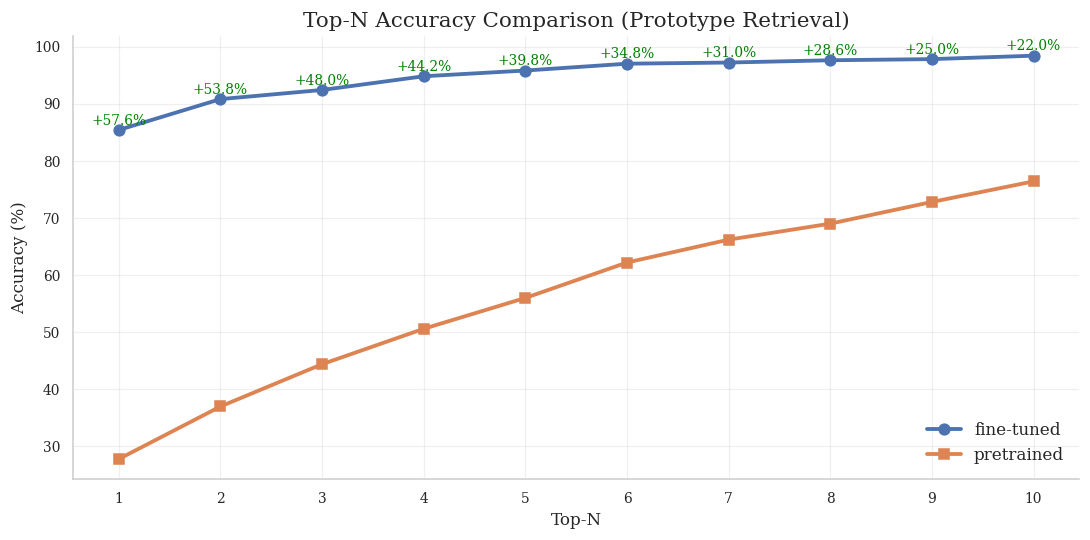

In [26]:

# Top-N accuracy curves for prototype retrieval
def topn_accuracy(pred_sim, labels, n_max=10):
    """pred_sim: (n_test, n_classes) similarity matrix, labels: true chimp names"""
    lab = np.array(labels)
    order = np.argsort(-pred_sim, axis=1)
    proto_names_list = ft_proto_names  # reuse from earlier
    accs = []
    for n in range(1, n_max + 1):
        pred_n = [proto_names_list[order[i, j]] for i in range(len(lab)) for j in range(n)]
        # For each query, check if true label in top-n
        hits = sum(1 for i in range(len(lab)) if lab[i] in [proto_names_list[order[i, j]] for j in range(n)])
        accs.append(100 * hits / len(lab))
    return accs

ft_topn = topn_accuracy(ft_proto_sim, ft_test_labels)
pt_topn = topn_accuracy(pt_proto_sim, pt_test_labels)

topn_df = pd.DataFrame({
    "top_n": list(range(1, 11)),
    "fine_tuned": ft_topn,
    "pretrained": pt_topn,
    "delta": [ft_topn[i] - pt_topn[i] for i in range(10)],
})

print("Top-N Accuracy (prototype retrieval):")
display(topn_df.style.format({"fine_tuned": "{:.2f}%", "pretrained": "{:.2f}%", "delta": "{:+.2f}%"}))
topn_df.to_csv(EVAL_OUT_DIR / "test_topn_accuracy.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(topn_df["top_n"], topn_df["fine_tuned"], marker="o", lw=2.5, label="fine-tuned", color="C0", markersize=7)
ax.plot(topn_df["top_n"], topn_df["pretrained"], marker="s", lw=2.5, label="pretrained", color="C1", markersize=7)
ax.set_xlabel("Top-N"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Top-N Accuracy Comparison (Prototype Retrieval)")
ax.set_xticks(topn_df["top_n"])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
for i, row in topn_df.iterrows():
    delta = row["delta"]
    y_pos = max(row["fine_tuned"], row["pretrained"]) + 1
    ax.text(row["top_n"], y_pos, f"{delta:+.1f}%", ha="center", fontsize=9, color="green" if delta > 0 else "red")
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_topn_accuracy_curves.png", dpi=200)
plt.show()



## 7d) Top-N Accuracy Curves Comparison

Compare top-1 through top-10 accuracy for both models using prototype retrieval.


Prototype Prediction Agreement (fine-tuned vs pretrained):
  Total test images: 500
  Both correct: 137 (27.4%)
  Fine-tuned only correct: 290 (58.0%)
  Pretrained only correct: 2 (0.4%)
  Both wrong, same pred: 35 (7.0%)
  Both wrong, disagree: 36 (7.2%)


,category,count,pct
0,both_correct,137,27.4%
1,ft_only_correct,290,58.0%
2,pt_only_correct,2,0.4%
3,both_wrong_same_pred,35,7.0%
4,both_wrong_diff_pred,36,7.2%


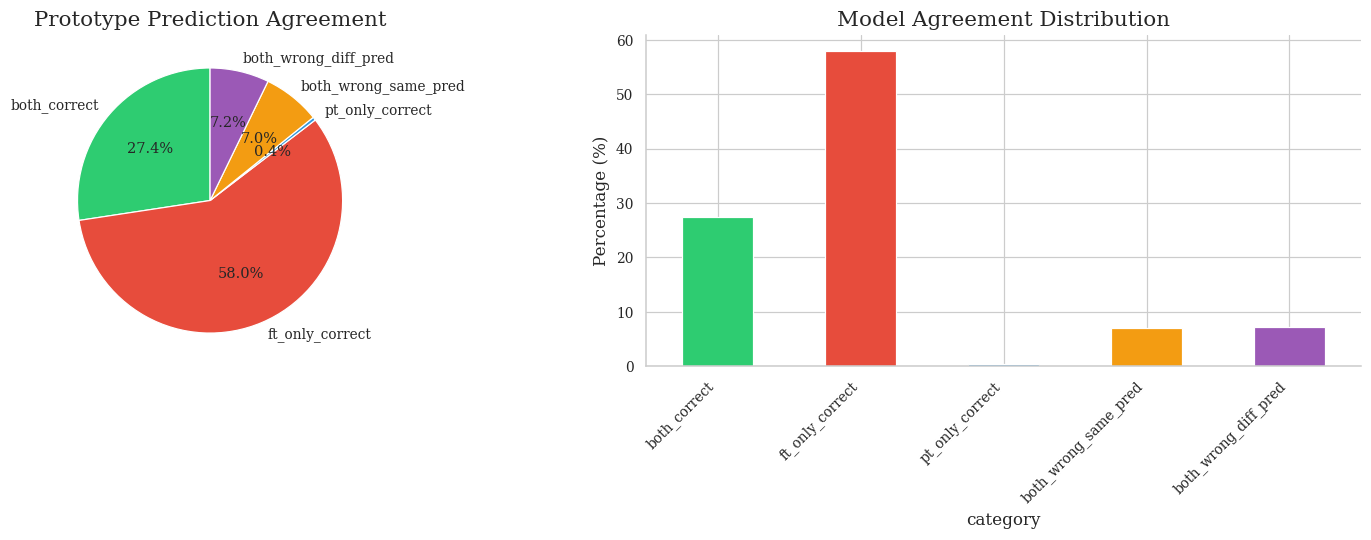


Cases where FINE-TUNED wins (290):


,image,true_chimp,pred_proto_ft,proto_margin_ft,pred_proto_pre,proto_margin_pre
3,AD_12.png,amadi,amadi,0.314419,penda,0.022943
5,AD_15.png,amadi,amadi,0.368678,tanganica,0.001937
6,AD_16.png,amadi,amadi,0.106181,lwama,0.000668
7,AD_17.png,amadi,amadi,0.067553,tingitingi,0.003282
8,AD_18.png,amadi,amadi,0.424990,penda,0.012499
9,AD_19.png,amadi,amadi,0.162962,lwama,0.000370
10,AD_21.png,amadi,amadi,0.370503,penda,0.017693
11,AD_22.png,amadi,amadi,0.434551,nganja,0.033034
12,AD_25.png,amadi,amadi,0.499677,tanganica,0.019772
13,AD_26.png,amadi,amadi,0.461992,nganja,0.001192



Cases where PRETRAINED wins (2):


,image,true_chimp,pred_proto_ft,proto_margin_ft,pred_proto_pre,proto_margin_pre
266,MG_24.png,malago,ivan,0.172236,malago,0.048506
275,MM_1.png,maniema,binasera,0.031389,maniema,0.042199


In [27]:

# Model agreement analysis
n_test = len(per_image)
proto_agree = (per_image["pred_proto_ft"] == per_image["pred_proto_pre"]).sum()
proto_agree_correct = ((per_image["pred_proto_ft"] == per_image["true_chimp"]) & 
                       (per_image["pred_proto_pre"] == per_image["true_chimp"])).sum()
proto_ft_only_correct = ((per_image["pred_proto_ft"] == per_image["true_chimp"]) & 
                         (per_image["pred_proto_pre"] != per_image["true_chimp"])).sum()
proto_pt_only_correct = ((per_image["pred_proto_ft"] != per_image["true_chimp"]) & 
                         (per_image["pred_proto_pre"] == per_image["true_chimp"])).sum()
both_wrong = ((per_image["pred_proto_ft"] != per_image["true_chimp"]) & 
              (per_image["pred_proto_pre"] != per_image["true_chimp"]) &
              (per_image["pred_proto_ft"] == per_image["pred_proto_pre"])).sum()
disagree_both_wrong = ((per_image["pred_proto_ft"] != per_image["true_chimp"]) & 
                       (per_image["pred_proto_pre"] != per_image["true_chimp"]) &
                       (per_image["pred_proto_ft"] != per_image["pred_proto_pre"])).sum()

agreement_summary = pd.DataFrame([{
    "category": "both_correct",
    "count": proto_agree_correct,
    "pct": 100 * proto_agree_correct / n_test,
}, {
    "category": "ft_only_correct",
    "count": proto_ft_only_correct,
    "pct": 100 * proto_ft_only_correct / n_test,
}, {
    "category": "pt_only_correct",
    "count": proto_pt_only_correct,
    "pct": 100 * proto_pt_only_correct / n_test,
}, {
    "category": "both_wrong_same_pred",
    "count": both_wrong,
    "pct": 100 * both_wrong / n_test,
}, {
    "category": "both_wrong_diff_pred",
    "count": disagree_both_wrong,
    "pct": 100 * disagree_both_wrong / n_test,
}])

print("Prototype Prediction Agreement (fine-tuned vs pretrained):")
print(f"  Total test images: {n_test}")
print(f"  Both correct: {proto_agree_correct} ({100*proto_agree_correct/n_test:.1f}%)")
print(f"  Fine-tuned only correct: {proto_ft_only_correct} ({100*proto_ft_only_correct/n_test:.1f}%)")
print(f"  Pretrained only correct: {proto_pt_only_correct} ({100*proto_pt_only_correct/n_test:.1f}%)")
print(f"  Both wrong, same pred: {both_wrong} ({100*both_wrong/n_test:.1f}%)")
print(f"  Both wrong, disagree: {disagree_both_wrong} ({100*disagree_both_wrong/n_test:.1f}%)")
display(agreement_summary.style.format({"pct": "{:.1f}%"}))
agreement_summary.to_csv(EVAL_OUT_DIR / "test_model_agreement_summary.csv", index=False)

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6"]
axes[0].pie(agreement_summary["count"], labels=agreement_summary["category"], autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[0].set_title("Prototype Prediction Agreement")
# Bar chart
agreement_summary.plot(x="category", y="pct", kind="bar", ax=axes[1], legend=False, color=colors)
axes[1].set_ylabel("Percentage (%)"); axes[1].set_title("Model Agreement Distribution")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "test_model_agreement_distribution.png", dpi=200)
plt.show()

# Extract cases where one model is right and the other wrong
if proto_ft_only_correct > 0:
    ft_wins = per_image[(per_image["pred_proto_ft"] == per_image["true_chimp"]) & 
                        (per_image["pred_proto_pre"] != per_image["true_chimp"])].copy()
    print(f"\nCases where FINE-TUNED wins ({len(ft_wins)}):")
    display(ft_wins[["image", "true_chimp", "pred_proto_ft", "proto_margin_ft", 
                     "pred_proto_pre", "proto_margin_pre"]].head(10))
    ft_wins.to_csv(EVAL_OUT_DIR / "test_cases_ft_wins.csv", index=False)

if proto_pt_only_correct > 0:
    pt_wins = per_image[(per_image["pred_proto_ft"] != per_image["true_chimp"]) & 
                        (per_image["pred_proto_pre"] == per_image["true_chimp"])].copy()
    print(f"\nCases where PRETRAINED wins ({len(pt_wins)}):")
    display(pt_wins[["image", "true_chimp", "pred_proto_ft", "proto_margin_ft", 
                     "pred_proto_pre", "proto_margin_pre"]].head(10))
    pt_wins.to_csv(EVAL_OUT_DIR / "test_cases_pt_wins.csv", index=False)



## 7c) Model Agreement & Disagreement Analysis

Analyze where fine-tuned and pretrained models agree vs disagree in their predictions.


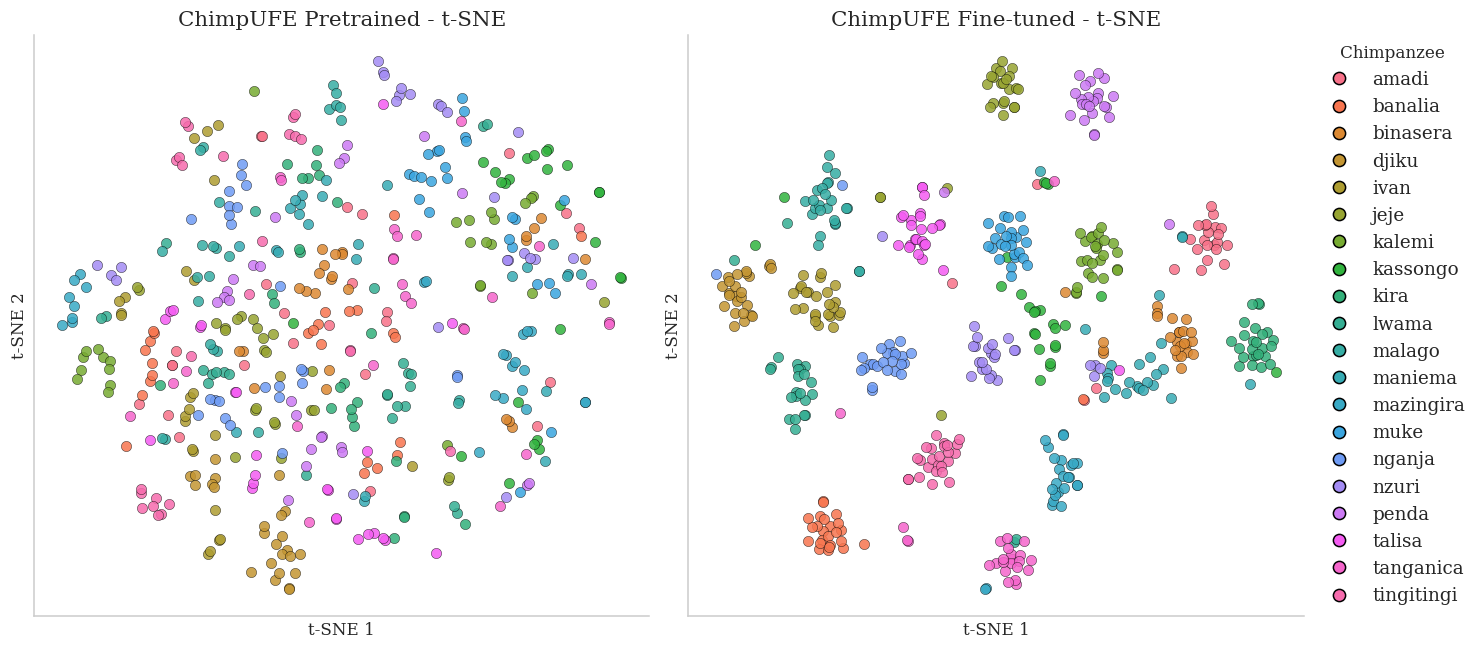

In [28]:
def plot_embedding_projection_tsne_side_by_side(
    emb_left,
    labels_left,
    emb_right,
    labels_right,
    title_left="Fine-tuned",
    title_right="Pretrained",
    savepath=None
):
    labels_left = np.array(labels_left)
    labels_right = np.array(labels_right)

    # Use the same identity order and same colors in both plots
    unique_ids = sorted(set(labels_left.tolist()) | set(labels_right.tolist()))
    palette = sns.color_palette("husl", len(unique_ids))
    color_map = {chimp: palette[i] for i, chimp in enumerate(unique_ids)}

    # t-SNE for each embedding space separately
    perplexity_left = min(30, max(5, len(emb_left) // 4))
    perplexity_right = min(30, max(5, len(emb_right) // 4))

    emb_left_tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_left,
        init="pca",
        learning_rate="auto"
    ).fit_transform(emb_left)

    emb_right_tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_right,
        init="pca",
        learning_rate="auto"
    ).fit_transform(emb_right)

    # Create side-by-side figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ------------------------------------------------------------------
    # Left plot
    # ------------------------------------------------------------------
    ax = axes[0]
    for chimp in unique_ids:
        idx = np.where(labels_left == chimp)[0]
        if len(idx) == 0:
            continue

        ax.scatter(
            emb_left_tsne[idx, 0],
            emb_left_tsne[idx, 1],
            label=chimp,
            alpha=0.85,
            s=45,
            color=color_map[chimp],
            edgecolors="black",
            linewidths=0.3
        )

    ax.set_title(f"{title_left} - t-SNE")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")


    # ------------------------------------------------------------------
    # Right plot
    # ------------------------------------------------------------------
    ax = axes[1]
    for chimp in unique_ids:
        idx = np.where(labels_right == chimp)[0]
        if len(idx) == 0:
            continue

        ax.scatter(
            emb_right_tsne[idx, 0],
            emb_right_tsne[idx, 1],
            label=chimp,
            alpha=0.85,
            s=45,
            color=color_map[chimp],
            edgecolors="black",
            linewidths=0.3
        )

    ax.set_title(f"{title_right} - t-SNE")
    ax.set_xticks([])
    ax.set_yticks([])

    # ------------------------------------------------------------------
    # Shared legend
    # ------------------------------------------------------------------
    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=chimp,
            markerfacecolor=color_map[chimp],
            markeredgecolor="black",
            markersize=8
        )
        for chimp in unique_ids
    ]

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")


    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.85, 0.5),
        frameon=False,
        fontsize=12,
        title="Chimpanzee",
        title_fontsize=11
    )

    plt.tight_layout(rect=[0, 0, 0.86, 1])

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
plot_embedding_projection_tsne_side_by_side(
    pt_test_emb,
    pt_test_labels,
    ft_test_emb,
    ft_test_labels,
    title_left="ChimpUFE Pretrained",
    title_right="ChimpUFE Fine-tuned",
    savepath=EVAL_OUT_DIR / "test_projection_fine_tuned_vs_pretrained.png"
)

[1] AD_1.png
  true                  : amadi
  fine-tuned head       :        amadi (p=0.908)  ok=True
  fine-tuned prototype  :        amadi (margin=0.105) ok=True
  pretrained prototype  :        amadi (margin=0.021) ok=True


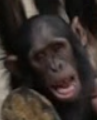

[2] AD_10.png
  true                  : amadi
  fine-tuned head       :        amadi (p=1.000)  ok=True
  fine-tuned prototype  :        amadi (margin=0.466) ok=True
  pretrained prototype  :        amadi (margin=0.005) ok=True


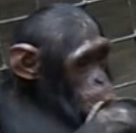

[3] AD_11.png
  true                  : amadi
  fine-tuned head       :        amadi (p=1.000)  ok=True
  fine-tuned prototype  :        amadi (margin=0.471) ok=True
  pretrained prototype  :        amadi (margin=0.026) ok=True


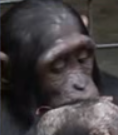

In [29]:
# =============================================================================
# 9) Visual review — show test images with all predictions
# =============================================================================
from IPython.display import display

def review_predictions(df, image_paths, max_images=None, only_failures=False):
    items = list(zip(df.iterrows(), image_paths))
    if only_failures:
        items = [it for it in items if not it[0][1]["head_correct"]]
    if max_images is not None:
        items = items[:max_images]
    for (i, row), pth in items:
        print("=" * 80)
        print(f"[{i+1}] {row['image']}")
        print(f"  true                  : {row['true_chimp']}")
        print(f"  fine-tuned head       : {row['pred_head_ft']:>12s} "
              f"(p={row['head_confidence']:.3f})  ok={bool(row['head_correct'])}")
        print(f"  fine-tuned prototype  : {row['pred_proto_ft']:>12s} "
              f"(margin={row['proto_margin_ft']:.3f}) ok={bool(row['proto_ft_correct'])}")
        print(f"  pretrained prototype  : {row['pred_proto_pre']:>12s} "
              f"(margin={row['proto_margin_pre']:.3f}) ok={bool(row['proto_pre_correct'])}")
        display(Image.open(pth).convert("RGB"))


# Examples (uncomment one):
# review_predictions(per_image, ft_test_paths, max_images=5)
# review_predictions(per_image, ft_test_paths, only_failures=True)
review_predictions(per_image, ft_test_paths, max_images=3)


In [30]:
# =============================================================================
# 10) FINAL SUMMARY — single dict written to test_eval_summary.json
# =============================================================================
summary = {
    "run_dir": str(RUN_DIR),
    "checkpoint": str(CKPT_PATH),
    "n_test_images": len(per_image),
    "classification_head": {
        "top1": top1, "top5": top5,
        "precision_macro": prec_m, "recall_macro": rec_m, "f1_macro": f1_m,
        "precision_weighted": prec_w, "recall_weighted": rec_w, "f1_weighted": f1_w,
        "per_class_accuracy": per_class_acc,
    },
    "retrieval_loo": {"fine_tuned": ft_retr, "pretrained": pt_retr},
    "retrieval_prototype": {"fine_tuned": ft_proto, "pretrained": pt_proto},
    "verification": {"fine_tuned": ft_ver, "pretrained": pt_ver},
    "embedding_geometry": {"fine_tuned": ft_geom, "pretrained": pt_geom},
    "image_level_accuracy": {
        "fine_tuned_head":      float(per_image.head_correct.mean()),
        "fine_tuned_prototype": float(per_image.proto_ft_correct.mean()),
        "pretrained_prototype": float(per_image.proto_pre_correct.mean()),
    },
    "model_agreement": {
        "both_correct": int(proto_agree_correct),
        "ft_only_correct": int(proto_ft_only_correct),
        "pt_only_correct": int(proto_pt_only_correct),
        "both_wrong_same": int(both_wrong),
        "both_wrong_diff": int(disagree_both_wrong),
    },
    "top_n_accuracy": {
        "top_1": {"fine_tuned": float(topn_df.iloc[0]["fine_tuned"]), 
                  "pretrained": float(topn_df.iloc[0]["pretrained"])},
        "top_5": {"fine_tuned": float(topn_df.iloc[4]["fine_tuned"]), 
                  "pretrained": float(topn_df.iloc[4]["pretrained"])},
        "top_10": {"fine_tuned": float(topn_df.iloc[9]["fine_tuned"]), 
                   "pretrained": float(topn_df.iloc[9]["pretrained"])},
    },
    "ranking_agreement": {
        "kendall_tau_mean": float(ranking_df["kendall_tau"].mean()),
        "kendall_tau_std": float(ranking_df["kendall_tau"].std()),
        "top5_overlap_mean": float(ranking_df["top5_overlap"].mean()),
        "top5_overlap_std": float(ranking_df["top5_overlap"].std()),
    },
    "embedding_quality": {
        "fine_tuned": ft_emb_stats,
        "pretrained": pt_emb_stats,
    },
}
with open(EVAL_OUT_DIR / "test_eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)

print("All evaluation artifacts written to:")
print(f"  {EVAL_OUT_DIR}")
for p in sorted(EVAL_OUT_DIR.iterdir()):
    print(f"  - {p.name}")


All evaluation artifacts written to:
  /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55
  - cmc_curve.png
  - cmc_map_summary.csv
  - data_f1_correlation_table_for_thesis.csv
  - data_performance_correlation_overview.png
  - data_performance_correlation_table.csv
  - data_performance_f1_residual_analysis.png
  - data_performance_identity_heatmap.png
  - per_identity_data_vs_performance_analysis.csv
  - test_cases_ft_wins.csv
  - test_cases_pt_wins.csv
  - test_classification_report.csv
  - test_classification_report.txt
  - test_cmc_curve_3way.png
  - test_comparison_3way.csv
  - test_comparison_3way_bars.png
  - test_comprehensive_comparison.csv
  - test_confidence_and_riskcov.pdf
  - test_confidence_and_riskcov.png
  - test_confusion_analysis_ft.csv
  - test_confusion_analysis_pt.csv
  - test_confusion_matrix.csv
  - test_confusion_matrix.png
  - test_confusion_matrix_facenetfc.png
  - test_confusion_matrix_finetun

In [31]:

# =============================================================================
# Comprehensive comparison table of all metrics
# =============================================================================
comprehensive_summary = pd.DataFrame([
    {
        "Metric Category": "Classification Head (FT only)",
        "Metric": "Top-1 Accuracy",
        "Fine-Tuned": f"{top1:.4f}",
        "Pretrained": "N/A",
        "Delta": "N/A",
    },
    {
        "Metric Category": "Classification Head (FT only)",
        "Metric": "Top-5 Accuracy",
        "Fine-Tuned": f"{top5:.4f}",
        "Pretrained": "N/A",
        "Delta": "N/A",
    },
    {
        "Metric Category": "Retrieval LoO",
        "Metric": "Top-1",
        "Fine-Tuned": f"{ft_retr['top1']:.4f}",
        "Pretrained": f"{pt_retr['top1']:.4f}",
        "Delta": f"{ft_retr['top1']-pt_retr['top1']:+.4f}",
    },
    {
        "Metric Category": "Retrieval LoO",
        "Metric": "Top-5",
        "Fine-Tuned": f"{ft_retr['top5']:.4f}",
        "Pretrained": f"{pt_retr['top5']:.4f}",
        "Delta": f"{ft_retr['top5']-pt_retr['top5']:+.4f}",
    },
    {
        "Metric Category": "Retrieval LoO",
        "Metric": "mAP",
        "Fine-Tuned": f"{ft_retr['mAP']:.4f}",
        "Pretrained": f"{pt_retr['mAP']:.4f}",
        "Delta": f"{ft_retr['mAP']-pt_retr['mAP']:+.4f}",
    },
    {
        "Metric Category": "Prototype Retrieval",
        "Metric": "Top-1",
        "Fine-Tuned": f"{ft_proto['top1']:.4f}",
        "Pretrained": f"{pt_proto['top1']:.4f}",
        "Delta": f"{ft_proto['top1']-pt_proto['top1']:+.4f}",
    },
    {
        "Metric Category": "Prototype Retrieval",
        "Metric": "Top-5",
        "Fine-Tuned": f"{ft_proto['top5']:.4f}",
        "Pretrained": f"{pt_proto['top5']:.4f}",
        "Delta": f"{ft_proto['top5']-pt_proto['top5']:+.4f}",
    },
    {
        "Metric Category": "Prototype Retrieval",
        "Metric": "Margin Mean",
        "Fine-Tuned": f"{ft_proto['margin_mean']:.3f}",
        "Pretrained": f"{pt_proto['margin_mean']:.3f}",
        "Delta": f"{ft_proto['margin_mean']-pt_proto['margin_mean']:+.3f}",
    },
    {
        "Metric Category": "Verification",
        "Metric": "ROC-AUC",
        "Fine-Tuned": f"{ft_ver['auc']:.4f}",
        "Pretrained": f"{pt_ver['auc']:.4f}",
        "Delta": f"{ft_ver['auc']-pt_ver['auc']:+.4f}",
    },
    {
        "Metric Category": "Verification",
        "Metric": "EER",
        "Fine-Tuned": f"{ft_ver['eer']:.4f}",
        "Pretrained": f"{pt_ver['eer']:.4f}",
        "Delta": f"{ft_ver['eer']-pt_ver['eer']:+.4f}",
    },
    {
        "Metric Category": "Embedding Geometry",
        "Metric": "Intra-class mean",
        "Fine-Tuned": f"{ft_geom['intra_mean']:.4f}",
        "Pretrained": f"{pt_geom['intra_mean']:.4f}",
        "Delta": f"{ft_geom['intra_mean']-pt_geom['intra_mean']:+.4f}",
    },
    {
        "Metric Category": "Embedding Geometry",
        "Metric": "Inter-class mean",
        "Fine-Tuned": f"{ft_geom['inter_mean']:.4f}",
        "Pretrained": f"{pt_geom['inter_mean']:.4f}",
        "Delta": f"{ft_geom['inter_mean']-pt_geom['inter_mean']:+.4f}",
    },
    {
        "Metric Category": "Embedding Geometry",
        "Metric": "Separation (intra-inter)",
        "Fine-Tuned": f"{ft_geom['separation']:.4f}",
        "Pretrained": f"{pt_geom['separation']:.4f}",
        "Delta": f"{ft_geom['separation']-pt_geom['separation']:+.4f}",
    },
    {
        "Metric Category": "Embedding Geometry",
        "Metric": "Silhouette (cosine)",
        "Fine-Tuned": f"{ft_geom['silhouette_cos']:.4f}",
        "Pretrained": f"{pt_geom['silhouette_cos']:.4f}",
        "Delta": f"{ft_geom['silhouette_cos']-pt_geom['silhouette_cos']:+.4f}",
    },
    {
        "Metric Category": "Top-N Accuracy",
        "Metric": "Top-1",
        "Fine-Tuned": f"{topn_df.iloc[0]['fine_tuned']:.2f}%",
        "Pretrained": f"{topn_df.iloc[0]['pretrained']:.2f}%",
        "Delta": f"{topn_df.iloc[0]['delta']:+.2f}%",
    },
    {
        "Metric Category": "Top-N Accuracy",
        "Metric": "Top-5",
        "Fine-Tuned": f"{topn_df.iloc[4]['fine_tuned']:.2f}%",
        "Pretrained": f"{topn_df.iloc[4]['pretrained']:.2f}%",
        "Delta": f"{topn_df.iloc[4]['delta']:+.2f}%",
    },
    {
        "Metric Category": "Ranking Agreement",
        "Metric": "Kendall Tau (mean)",
        "Fine-Tuned": f"{ranking_df['kendall_tau'].mean():.4f}",
        "Pretrained": "—",
        "Delta": "—",
    },
    {
        "Metric Category": "Ranking Agreement",
        "Metric": "Top-5 Overlap (mean)",
        "Fine-Tuned": f"{ranking_df['top5_overlap'].mean():.4f}",
        "Pretrained": "—",
        "Delta": "—",
    },
])

print("=" * 100)
print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
print("=" * 100)
display(comprehensive_summary)
comprehensive_summary.to_csv(EVAL_OUT_DIR / "test_comprehensive_comparison.csv", index=False)

# Summary statistics
print("\n" + "=" * 100)
print("KEY TAKEAWAYS")
print("=" * 100)
improvements = []
if ft_retr["top1"] > pt_retr["top1"]:
    improvements.append(f"✓ Retrieval top-1 improved by {100*(ft_retr['top1']-pt_retr['top1']):.2f}%")
if ft_proto["top1"] > pt_proto["top1"]:
    improvements.append(f"✓ Prototype retrieval top-1 improved by {100*(ft_proto['top1']-pt_proto['top1']):.2f}%")
if ft_ver["auc"] > pt_ver["auc"]:
    improvements.append(f"✓ Verification AUC improved by {100*(ft_ver['auc']-pt_ver['auc']):.2f}%")
if ft_geom["separation"] > pt_geom["separation"]:
    improvements.append(f"✓ Embedding separation improved by {100*(ft_geom['separation']-pt_geom['separation']):.2f}%")

improvements.append(f"✓ Agreement: {proto_agree_correct} ({100*proto_agree_correct/n_test:.1f}%) both models correct")
improvements.append(f"✓ Model gains: FT wins {proto_ft_only_correct} cases, PT wins {proto_pt_only_correct} cases")
improvements.append(f"✓ Ranking agreement: Kendall tau = {ranking_df['kendall_tau'].mean():.3f}")

for imp in improvements:
    print(imp)


COMPREHENSIVE MODEL COMPARISON SUMMARY


,Metric Category,Metric,Fine-Tuned,Pretrained,Delta
0,Classification Head (FT only),Top-1 Accuracy,0.8680,N/A,N/A
1,Classification Head (FT only),Top-5 Accuracy,0.9620,N/A,N/A
2,Retrieval LoO,Top-1,0.9300,0.7620,+0.1680
3,Retrieval LoO,Top-5,0.9560,0.9060,+0.0500
4,Retrieval LoO,mAP,0.7495,0.2514,+0.4981
5,Prototype Retrieval,Top-1,0.8540,0.2780,+0.5760
6,Prototype Retrieval,Top-5,0.9580,0.5600,+0.3980
7,Prototype Retrieval,Margin Mean,0.289,0.044,+0.245
8,Verification,ROC-AUC,0.9281,0.6936,+0.2345
9,Verification,EER,0.1470,0.3641,-0.2171



KEY TAKEAWAYS
✓ Retrieval top-1 improved by 16.80%
✓ Prototype retrieval top-1 improved by 57.60%
✓ Verification AUC improved by 23.45%
✓ Embedding separation improved by 23.87%
✓ Agreement: 137 (27.4%) both models correct
✓ Model gains: FT wins 290 cases, PT wins 2 cases
✓ Ranking agreement: Kendall tau = 0.030



## 11) COMPREHENSIVE MODEL COMPARISON SUMMARY

Final side-by-side comparison table of all key metrics.


## Rank-k CMC & mean Average Precision (mAP)

Treat the **test set as queries** and the **train set as gallery**. For each query, gallery
images are ranked by cosine similarity in embedding space.

- **Rank-k** = fraction of queries whose correct identity appears in the top-$k$ gallery items.
- **AP(q)** = mean of `Precision(k)` over the ranks $k$ where a correct gallery item appears.
- **mAP** = average of AP over all queries.

Both metrics are reported for the **pretrained** ChimpUFE backbone and the **fine-tuned** model.


In [32]:
# =============================================================================
# Rank-k CMC + mAP
#   queries = test set, gallery = train set (per-image, NOT prototypes)
# =============================================================================
def cmc_and_map(query_emb: np.ndarray, query_labels, gallery_emb: np.ndarray,
                gallery_labels, ranks=(1, 5, 10, 20)):
    q = query_emb / (np.linalg.norm(query_emb, axis=1, keepdims=True) + 1e-12)
    g = gallery_emb / (np.linalg.norm(gallery_emb, axis=1, keepdims=True) + 1e-12)
    sims = q @ g.T                                                  # (Nq, Ng)
    order = np.argsort(-sims, axis=1)                                # rank gallery per query
    g_lbl = np.asarray(gallery_labels)
    q_lbl = np.asarray(query_labels)
    matches = (g_lbl[order] == q_lbl[:, None])                       # (Nq, Ng) bool

    # CMC: per-query whether a correct match exists within top-k
    Nq, Ng = matches.shape
    cmc = matches.cumsum(axis=1) > 0                                 # (Nq, Ng)
    rank_acc = {k: float(cmc[:, k - 1].mean()) for k in ranks if k <= Ng}

    # mAP: average over queries of (mean precision at correct hits)
    cum_correct = matches.cumsum(axis=1).astype(np.float64)
    ks = np.arange(1, Ng + 1, dtype=np.float64)
    precision_at_k = cum_correct / ks                                # (Nq, Ng)
    n_correct = matches.sum(axis=1)
    valid = n_correct > 0
    ap = np.zeros(Nq, dtype=np.float64)
    ap[valid] = (precision_at_k[valid] * matches[valid]).sum(axis=1) / n_correct[valid]
    mAP = float(ap[valid].mean()) if valid.any() else float("nan")
    return rank_acc, mAP, ap, cmc.mean(axis=0)                       # also return full CMC curve


RANKS = (1, 5, 10, 20)

pt_ranks, pt_mAP, pt_ap, pt_cmc_curve = cmc_and_map(
    pt_test_emb, pt_test_labels, pt_train_emb, pt_train_labels, ranks=RANKS,
)
ft_ranks, ft_mAP, ft_ap, ft_cmc_curve = cmc_and_map(
    ft_test_emb, ft_test_labels, ft_train_emb, ft_train_labels, ranks=RANKS,
)

cmc_map_df = pd.DataFrame({
    "Metric": [f"Rank-{k}" for k in RANKS] + ["mAP"],
    "Pretrained":  [pt_ranks[k] for k in RANKS] + [pt_mAP],
    "Fine-tuned":  [ft_ranks[k] for k in RANKS] + [ft_mAP],
})
cmc_map_df["Δ (FT − PT)"] = cmc_map_df["Fine-tuned"] - cmc_map_df["Pretrained"]
cmc_map_df_disp = cmc_map_df.copy()
for c in ["Pretrained", "Fine-tuned", "Δ (FT − PT)"]:
    cmc_map_df_disp[c] = cmc_map_df_disp[c].map(lambda v: f"{v*100:.2f}%")
print(cmc_map_df_disp.to_string(index=False))

cmc_map_df.to_csv(EVAL_OUT_DIR / "cmc_map_summary.csv", index=False)
print(f"\nSaved -> {EVAL_OUT_DIR / 'cmc_map_summary.csv'}")


 Metric Pretrained Fine-tuned Δ (FT − PT)
 Rank-1     27.60%     85.40%      57.80%
 Rank-5     42.20%     87.00%      44.80%
Rank-10     50.40%     88.00%      37.60%
Rank-20     59.60%     89.20%      29.60%
    mAP     18.06%     82.96%      64.90%

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/cmc_map_summary.csv


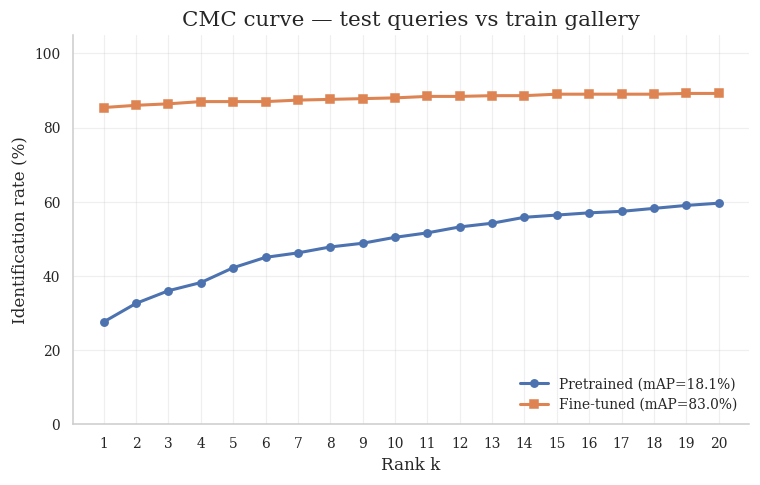

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/cmc_curve.png


In [33]:
# =============================================================================
# CMC curve plot (Rank-1 .. Rank-K) - pretrained vs fine-tuned
# =============================================================================
K_PLOT = min(20, len(pt_cmc_curve), len(ft_cmc_curve))
xs = np.arange(1, K_PLOT + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs, pt_cmc_curve[:K_PLOT] * 100, marker="o", lw=2, label=f"Pretrained (mAP={pt_mAP*100:.1f}%)")
ax.plot(xs, ft_cmc_curve[:K_PLOT] * 100, marker="s", lw=2, label=f"Fine-tuned (mAP={ft_mAP*100:.1f}%)")
ax.set_xlabel("Rank k")
ax.set_ylabel("Identification rate (%)")
ax.set_title("CMC curve — test queries vs train gallery")
ax.set_xticks(xs)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / "cmc_curve.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {EVAL_OUT_DIR / 'cmc_curve.png'}")


## Single-image inference demo

Pick any image on disk and run the fine-tuned model on it. The model returns
the top-k most likely chimpanzee identities along with their confidence
(softmax over cosine-similarity to the train-set prototypes) and shows the
nearest gallery image for each candidate.


In [34]:
# =============================================================================
# Identify-a-chimp helper
#
#   identify_chimp(path, top_k=5, show=True)
#       -> returns a DataFrame with the top_k candidates and their scores,
#          and (optionally) plots the query side-by-side with the closest
#          training image of the predicted identity.
# =============================================================================
from collections import defaultdict

# Build per-class L2-normalised prototypes from the (already-loaded) training
# embeddings of the fine-tuned model. Done once, reused for every query.
_ft_train_emb_n = ft_train_emb / (np.linalg.norm(ft_train_emb, axis=1, keepdims=True) + 1e-12)
_per_class_idx = defaultdict(list)
for i, lbl in enumerate(ft_train_labels):
    _per_class_idx[lbl].append(i)

_class_names_sorted = sorted(_per_class_idx.keys())
_proto_matrix = np.stack([
    _ft_train_emb_n[_per_class_idx[c]].mean(axis=0) for c in _class_names_sorted
])
_proto_matrix /= (np.linalg.norm(_proto_matrix, axis=1, keepdims=True) + 1e-12)


def identify_chimp(image_path, top_k: int = 5, show: bool = True, temperature: float = 10.0):
    image_path = Path(image_path)
    assert image_path.exists(), f"File not found: {image_path}"

    img = Image.open(image_path).convert("RGB")
    x = eval_tfm(img).unsqueeze(0).to(device, memory_format=torch.channels_last)

    fine_model.eval()
    with torch.no_grad():
        feat = F.normalize(fine_model.features(x), dim=1).cpu().numpy()[0]

    sims = _proto_matrix @ feat                                      # (num_classes,)
    # softmax with temperature for "confidence-looking" scores
    s = sims * temperature
    probs = np.exp(s - s.max())
    probs /= probs.sum()

    order = np.argsort(-sims)[:top_k]
    df = pd.DataFrame({
        "rank":       np.arange(1, top_k + 1),
        "chimp":      [_class_names_sorted[i] for i in order],
        "cosine_sim": sims[order],
        "confidence": probs[order],
    })

    if show:
        # Find the single closest training image for each top candidate
        thumbs = []
        for cls in df["chimp"]:
            idxs = _per_class_idx[cls]
            class_sims = _ft_train_emb_n[idxs] @ feat
            best = idxs[int(np.argmax(class_sims))]
            thumbs.append((cls, ft_train_paths[best], float(class_sims.max())))

        n = len(thumbs) + 1
        fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.2))
        axes[0].imshow(img)
        axes[0].set_title(f"QUERY\n{image_path.name}", fontsize=9)
        axes[0].axis("off")

        for ax, (cls, path, sim), conf in zip(axes[1:], thumbs, df["confidence"]):
            try:
                ax.imshow(Image.open(path).convert("RGB"))
            except Exception:
                ax.text(0.5, 0.5, "?", ha="center", va="center")
            ax.set_title(f"{cls}\nsim={sim:.2f}  conf={conf*100:.1f}%", fontsize=9)
            ax.axis("off")
        plt.suptitle(f"Predicted: {df['chimp'].iloc[0]}  "
                     f"(confidence {df['confidence'].iloc[0]*100:.1f}%)",
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.show()

    return df


print(f"Ready. {len(_class_names_sorted)} class prototypes built.")
print("Usage:  identify_chimp('/path/to/image.jpg', top_k=5)")


Ready. 20 class prototypes built.
Usage:  identify_chimp('/path/to/image.jpg', top_k=5)


In [35]:
# =============================================================================
# 12c) FaceNet-FC — all metrics (reuses functions from §2–5 + §Rank-k)
# =============================================================================
fn_retr = retrieval_metrics_loo(fn_test_emb, fn_test_labels)

fn_proto, fn_pred_proto, fn_proto_sim, fn_proto_names, fn_margins = proto_eval(
    fn_test_emb, fn_test_labels, fn_train_emb, fn_train_labels)

fn_ver, fn_s, fn_y = verification_metrics(fn_test_emb, fn_test_labels)

fn_geom, fn_intra, fn_inter = intra_inter_stats(fn_test_emb, fn_test_labels)

fn_ranks, fn_mAP, fn_ap, fn_cmc_curve = cmc_and_map(
    fn_test_emb, fn_test_labels, fn_train_emb, fn_train_labels, ranks=RANKS)

print('FaceNet-FC  retrieval LOO :', fn_retr)
print('FaceNet-FC  prototype top1:', fn_proto['top1'])
print('FaceNet-FC  verification  :', fn_ver)
print(f'FaceNet-FC  Rank-k: {fn_ranks}  mAP={fn_mAP:.4f}')


FaceNet-FC  retrieval LOO : {'top1': 0.178, 'top5': 0.416, 'mAP': 0.09011075109642523, 'n': 500}
FaceNet-FC  prototype top1: 0.07
FaceNet-FC  verification  : {'auc': 0.5600878028070175, 'eer': 0.45567842105263157, 'n_pairs': 124750}
FaceNet-FC  Rank-k: {1: 0.072, 5: 0.12, 10: 0.144, 20: 0.176}  mAP=0.1273


In [36]:
# =============================================================================
# 12d) Three-way comparison: Fine-Tuned | Pretrained 340k | FaceNet-FC
# =============================================================================
comparison_3way = pd.DataFrame([
    {
        'Model':         'Fine-Tuned (intensive)',
        'Retr-LOO Top1': ft_retr['top1'],
        'Proto Top1':    ft_proto['top1'],
        'Proto Top5':    ft_proto['top5'],
        'Verif AUC':     ft_ver['auc'],
        'Verif EER':     ft_ver['eer'],
        'Geom Sep':      ft_geom['separation'],
        'Rank-1 CMC':    ft_ranks[1],
        'mAP':           ft_mAP,
    },
    {
        'Model':         'Pretrained 340k',
        'Retr-LOO Top1': pt_retr['top1'],
        'Proto Top1':    pt_proto['top1'],
        'Proto Top5':    pt_proto['top5'],
        'Verif AUC':     pt_ver['auc'],
        'Verif EER':     pt_ver['eer'],
        'Geom Sep':      pt_geom['separation'],
        'Rank-1 CMC':    pt_ranks[1],
        'mAP':           pt_mAP,
    },
    {
        'Model':         'FaceNet-FC (last year)',
        'Retr-LOO Top1': fn_retr['top1'],
        'Proto Top1':    fn_proto['top1'],
        'Proto Top5':    fn_proto['top5'],
        'Verif AUC':     fn_ver['auc'],
        'Verif EER':     fn_ver['eer'],
        'Geom Sep':      fn_geom['separation'],
        'Rank-1 CMC':    fn_ranks[1],
        'mAP':           fn_mAP,
    },
])
comparison_3way.set_index('Model', inplace=True)

numeric_cols = [c for c in comparison_3way.columns]
display(comparison_3way.style.format({c: '{:.4f}' for c in numeric_cols}))
comparison_3way.to_csv(EVAL_OUT_DIR / 'test_comparison_3way.csv')
print(f'Saved -> {EVAL_OUT_DIR / "test_comparison_3way.csv"}')


,Retr-LOO Top1,Proto Top1,Proto Top5,Verif AUC,Verif EER,Geom Sep,Rank-1 CMC,mAP
Model,,,,,,,,
Fine-Tuned (intensive),0.9300,0.8540,0.9580,0.9281,0.1470,0.3463,0.8540,0.8296
Pretrained 340k,0.7620,0.2780,0.5600,0.6936,0.3641,0.1076,0.2760,0.1806
FaceNet-FC (last year),0.1780,0.0700,0.3360,0.5601,0.4557,0.0717,0.0720,0.1273


Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_comparison_3way.csv


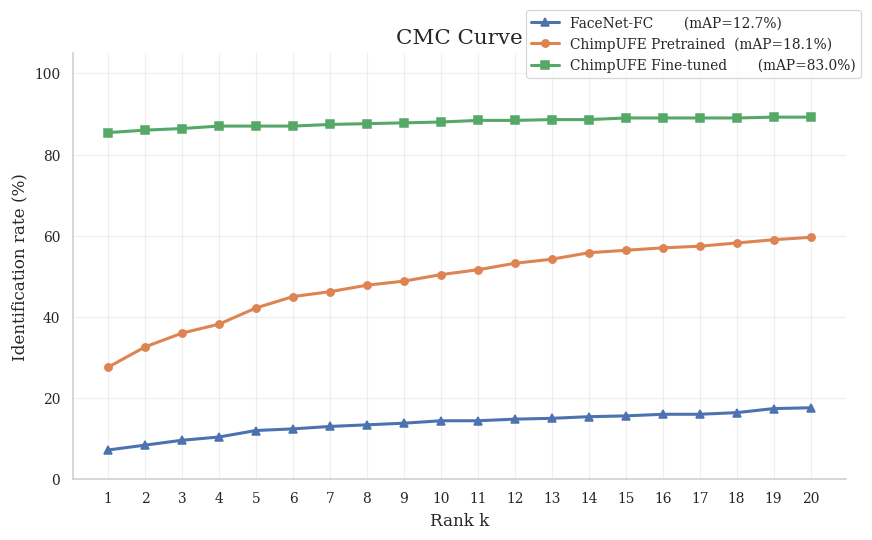

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_cmc_curve_3way.png


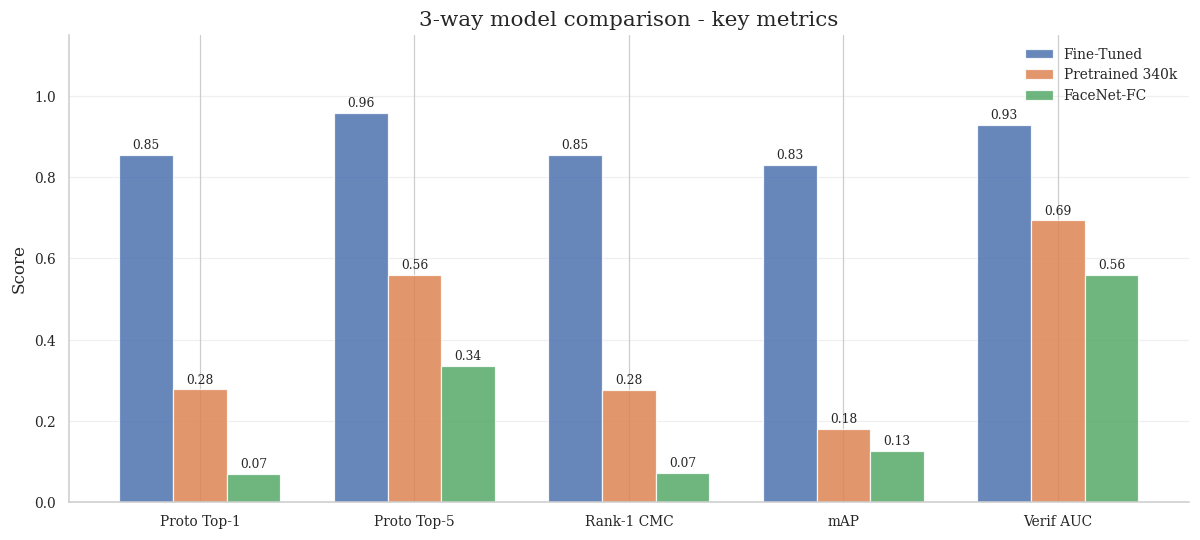

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_comparison_3way_bars.png


In [37]:
# =============================================================================
# 12e) Three-way CMC curve + bar chart of key metrics
# =============================================================================

# CMC curve
K_PLOT = min(20, len(pt_cmc_curve), len(ft_cmc_curve), len(fn_cmc_curve))
xs = np.arange(1, K_PLOT + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, fn_cmc_curve[:K_PLOT]*100, marker='^', lw=2,
        label=f'FaceNet-FC       (mAP={fn_mAP*100:.1f}%)')
ax.plot(xs, pt_cmc_curve[:K_PLOT]*100, marker='o', lw=2,
        label=f'ChimpUFE Pretrained  (mAP={pt_mAP*100:.1f}%)')
ax.plot(xs, ft_cmc_curve[:K_PLOT]*100, marker='s', lw=2,
        label=f'ChimpUFE Fine-tuned       (mAP={ft_mAP*100:.1f}%)')

ax.set_xlabel('Rank k'); ax.set_ylabel('Identification rate (%)')
ax.set_title('CMC Curve')
ax.set_xticks(xs); ax.set_ylim(0, 105); ax.grid(True, alpha=0.3)

ax.legend(
    loc='upper right',              # anchor point of legend box
    bbox_to_anchor=(1.02, 1.1),   # ✅ just outside top-right
    borderaxespad=0.,
    frameon=True
)

plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / 'test_cmc_curve_3way.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {EVAL_OUT_DIR / "test_cmc_curve_3way.png"}')

# Bar chart of key scalar metrics
metrics_keys  = ['Proto Top-1', 'Proto Top-5', 'Rank-1 CMC', 'mAP', 'Verif AUC']
ft_bar_vals = [ft_proto['top1'], ft_proto['top5'], ft_ranks[1], ft_mAP, ft_ver['auc']]
pt_bar_vals = [pt_proto['top1'], pt_proto['top5'], pt_ranks[1], pt_mAP, pt_ver['auc']]
fn_bar_vals = [fn_proto['top1'], fn_proto['top5'], fn_ranks[1], fn_mAP, fn_ver['auc']]

x = np.arange(len(metrics_keys)); w = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, ft_bar_vals, w, label='Fine-Tuned',      color='C0', alpha=0.85)
ax.bar(x,     pt_bar_vals, w, label='Pretrained 340k', color='C1', alpha=0.85)
ax.bar(x + w, fn_bar_vals, w, label='FaceNet-FC',      color='C2', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics_keys)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('3-way model comparison - key metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for xp, vals in zip(x, zip(ft_bar_vals, pt_bar_vals, fn_bar_vals)):
    for j, v in enumerate(vals):
        ax.text(xp + (j-1)*w, v + 0.015, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / 'test_comparison_3way_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved -> {EVAL_OUT_DIR / "test_comparison_3way_bars.png"}')

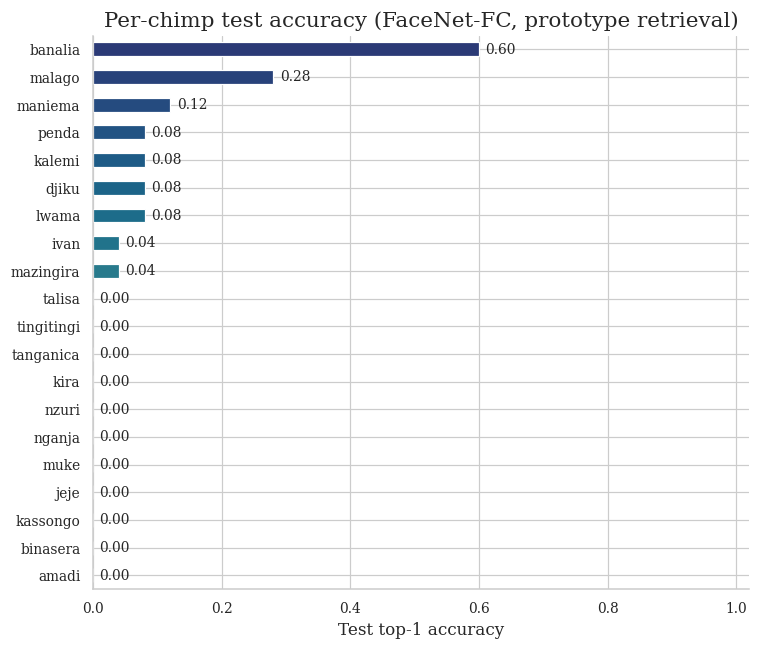

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_per_class_accuracy_facenet_fc.png


In [38]:
# =============================================================================
# 12f) Per-chimp accuracy — FaceNet-FC (prototype retrieval, gallery=train)
# =============================================================================
fn_pred_arr = np.array(fn_pred_proto)
fn_true_arr = np.array(fn_test_labels)

per_class_acc_fn = {}
for name in CANONICAL_NAMES:
    mask = fn_true_arr == name
    if not mask.any():
        continue
    per_class_acc_fn[name] = float((fn_pred_arr[mask] == name).mean())
pca_fn_series = pd.Series(per_class_acc_fn).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
pca_fn_series.plot(kind='barh', ax=ax,
                   color=sns.color_palette('crest', len(pca_fn_series)))
ax.set_xlim(0, 1.02); ax.set_xlabel('Test top-1 accuracy')
ax.set_title('Per-chimp test accuracy (FaceNet-FC, prototype retrieval)')
for i, v in enumerate(pca_fn_series.values):
    if not np.isnan(v):
        ax.text(min(v + 0.01, 1.0), i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(EVAL_OUT_DIR / 'test_per_class_accuracy_facenet_fc.png', dpi=200)
plt.show()
print(f'Saved -> {EVAL_OUT_DIR / "test_per_class_accuracy_facenet_fc.png"}')


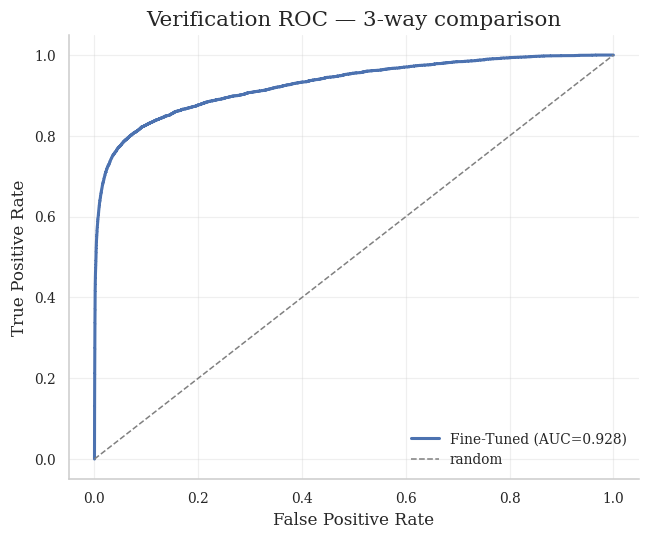

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_roc_3way.png


<Figure size 704x528 with 0 Axes>

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_roc_3way.png


<Figure size 704x528 with 0 Axes>

Saved -> /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/Evaluation/test_eval_chimpufe_ft_t3_frontal55/test_roc_3way.png


In [39]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, s, y, c, ls in [
    ('Fine-Tuned', ft_s, ft_y, 'C0', '-'),
    ('Pretrained 340k', pt_s, pt_y, 'C1', '-'),
    ('FaceNet-FC', fn_s, fn_y, 'C2', '-'),
]:
    fpr, tpr, _ = roc_curve(y, s)
    auc = roc_auc_score(y, s)
    ax.plot(fpr, tpr, lw=2, color=c, ls=ls, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('Verification ROC — 3-way comparison')
    ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(EVAL_OUT_DIR / 'test_roc_3way.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {EVAL_OUT_DIR / 'test_roc_3way.png'}")